In [57]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client.session"
)

In [58]:
import pandas as pd

dataset_file_path = '../dataset/df_preprocessed.csv'
df = pd.read_csv(dataset_file_path)

if df is not None:
  print(f"File {dataset_file_path} loaded successfully.")
else:
  print(f"Failed to load file {dataset_file_path}.")

File ../dataset/df_preprocessed.csv loaded successfully.


# 1. Gross Margin Rate sweet spot analysis

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [60]:
df_gmr_analysis = df.copy()

df_gmr_analysis = df_gmr_analysis[
    df_gmr_analysis["is_highest_price"] == 1
].copy()

In [61]:
bins = [-np.inf, -0.20, -0.10, 0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, np.inf]

labels = [
    "< -20%",
    "-20% to -10%",
    "-10% to 0%",
    "0% to 10%",
    "10% to 20%",
    "20% to 30%",
    "30% to 40%",
    "40% to 50%",
    "50% to 60%",
    "> 60%"
]

df_gmr_analysis["gmr_range"] = pd.cut(
    df_gmr_analysis["gross_margin_rate"],
    bins=bins,
    labels=labels,
    right=False
)

df_gmr_analysis["success"] = (df_gmr_analysis["convert_to_order"] == 0).astype(int)

In [62]:
gmr_sweet_spot = (
    df_gmr_analysis
    .groupby("gmr_range", observed=True)
    .agg(
        total_quotes=("quote_id", "count"),
        win_rate=("success", "mean"),
        avg_gmr=("gross_margin_rate", "mean"),
        avg_gross_profit=("estimated_gross_profit", "mean"),
        median_gross_profit=("estimated_gross_profit", "median"),
        total_potential_profit=("estimated_gross_profit", "sum")
    )
    .reset_index()
)

gmr_sweet_spot["expected_profit_per_quote"] = (
    gmr_sweet_spot["win_rate"] * gmr_sweet_spot["avg_gross_profit"]
)

gmr_sweet_spot["win_rate_pct"] = gmr_sweet_spot["win_rate"] * 100
gmr_sweet_spot

,gmr_range,total_quotes,win_rate,avg_gmr,avg_gross_profit,median_gross_profit,total_potential_profit,expected_profit_per_quote,win_rate_pct
0,< -20%,5,0.800000,-0.520260,-83147.720900,-49010.29000,-4.157386e+05,-66518.176720,80.000000
1,-20% to -10%,2,1.000000,-0.152100,-221350.429550,-221350.42955,-4.427009e+05,-221350.429550,100.000000
2,-10% to 0%,51,0.705882,-0.032547,-16255.871956,-4031.00000,-8.290495e+05,-11474.733146,70.588235
3,0% to 10%,298,0.523490,0.063741,23293.600312,12170.60000,6.941493e+06,12193.965264,52.348993
4,10% to 20%,601,0.314476,0.154758,51952.276744,30781.76000,3.122332e+07,16337.737612,31.447587
5,20% to 30%,549,0.522769,0.251040,143444.241229,68234.45832,7.875089e+07,74988.155251,52.276867
6,30% to 40%,930,0.281720,0.355375,185137.260504,103913.40960,1.721777e+08,52156.948658,28.172043
7,40% to 50%,1489,0.129617,0.441128,184511.621430,150517.62144,2.747378e+08,23915.878399,12.961719
8,50% to 60%,243,0.189300,0.554736,436329.649205,332132.40000,1.060281e+08,82597.382154,18.930041
9,> 60%,745,0.021477,0.641797,459445.480797,306820.80000,3.422869e+08,9867.285494,2.147651


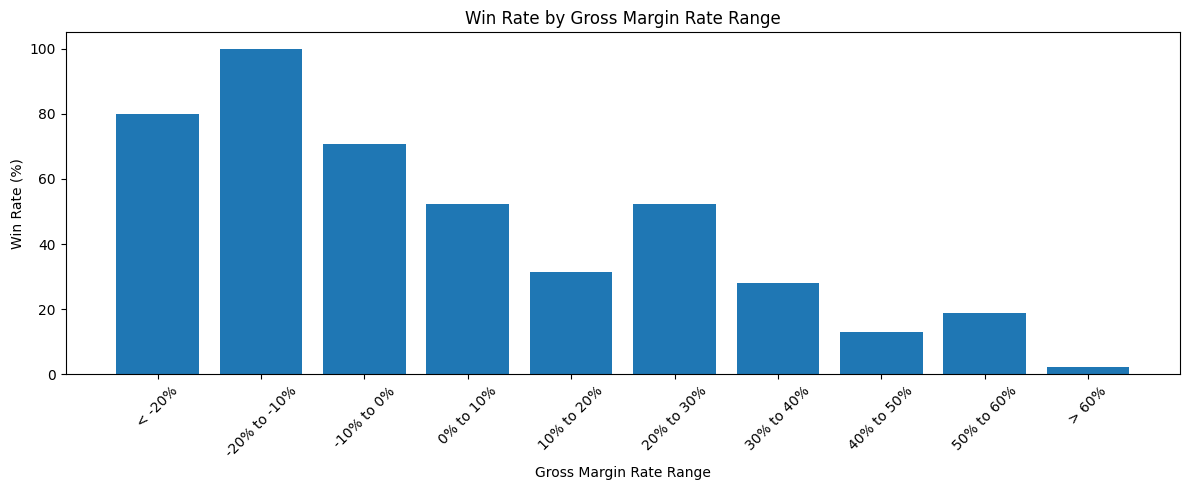

In [63]:
plt.figure(figsize=(12, 5))

plt.bar(
    gmr_sweet_spot["gmr_range"].astype(str),
    gmr_sweet_spot["win_rate_pct"]
)

plt.xticks(rotation=45)
plt.xlabel("Gross Margin Rate Range")
plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Gross Margin Rate Range")
plt.tight_layout()
plt.show()

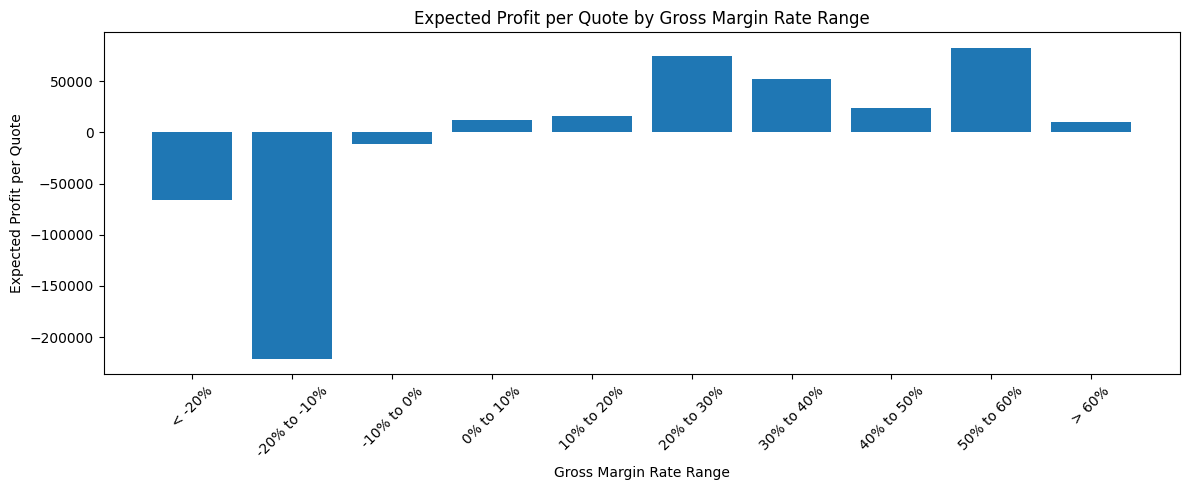

In [64]:
plt.figure(figsize=(12, 5))

plt.bar(
    gmr_sweet_spot["gmr_range"].astype(str),
    gmr_sweet_spot["expected_profit_per_quote"]
)

plt.xticks(rotation=45)
plt.xlabel("Gross Margin Rate Range")
plt.ylabel("Expected Profit per Quote")
plt.title("Expected Profit per Quote by Gross Margin Rate Range")
plt.tight_layout()
plt.show()

In [65]:
gmr_sweet_spot_display = gmr_sweet_spot.copy()

gmr_sweet_spot_display["win_rate_pct"] = (
    gmr_sweet_spot_display["win_rate"] * 100
).round(2)

gmr_sweet_spot_display["avg_gmr_pct"] = (
    gmr_sweet_spot_display["avg_gmr"] * 100
).round(2)

gmr_sweet_spot_display["avg_gross_profit"] = (
    gmr_sweet_spot_display["avg_gross_profit"].round(2)
)

gmr_sweet_spot_display["expected_profit_per_quote"] = (
    gmr_sweet_spot_display["expected_profit_per_quote"].round(2)
)

gmr_sweet_spot_display[
    [
        "gmr_range",
        "total_quotes",
        "win_rate_pct",
        "avg_gmr_pct",
        "avg_gross_profit",
        "expected_profit_per_quote"
    ]
]

,gmr_range,total_quotes,win_rate_pct,avg_gmr_pct,avg_gross_profit,expected_profit_per_quote
0,< -20%,5,80.00,-52.03,-83147.72,-66518.18
1,-20% to -10%,2,100.00,-15.21,-221350.43,-221350.43
2,-10% to 0%,51,70.59,-3.25,-16255.87,-11474.73
3,0% to 10%,298,52.35,6.37,23293.60,12193.97
4,10% to 20%,601,31.45,15.48,51952.28,16337.74
5,20% to 30%,549,52.28,25.10,143444.24,74988.16
6,30% to 40%,930,28.17,35.54,185137.26,52156.95
7,40% to 50%,1489,12.96,44.11,184511.62,23915.88
8,50% to 60%,243,18.93,55.47,436329.65,82597.38
9,> 60%,745,2.15,64.18,459445.48,9867.29


In [66]:
min_quotes = 30
min_win_rate = 0.30

sweet_spot_candidates = gmr_sweet_spot[
    (gmr_sweet_spot["total_quotes"] >= min_quotes) &
    (gmr_sweet_spot["win_rate"] >= min_win_rate) &
    (gmr_sweet_spot["expected_profit_per_quote"] > 0)
].copy()

sweet_spot_candidates = sweet_spot_candidates.sort_values(
    by="expected_profit_per_quote",
    ascending=False
)

sweet_spot_candidates

,gmr_range,total_quotes,win_rate,avg_gmr,avg_gross_profit,median_gross_profit,total_potential_profit,expected_profit_per_quote,win_rate_pct
5,20% to 30%,549,0.522769,0.251040,143444.241229,68234.45832,7.875089e+07,74988.155251,52.276867
4,10% to 20%,601,0.314476,0.154758,51952.276744,30781.76000,3.122332e+07,16337.737612,31.447587
3,0% to 10%,298,0.523490,0.063741,23293.600312,12170.60000,6.941493e+06,12193.965264,52.348993


# 4. Win probability prediction

In [67]:
df_model = df.copy()

price_variation = (
    df_model
    .groupby(["quote_id", "product"])["unit_price"]
    .transform("nunique")
)

df_model = df_model[
    (price_variation == 1) |
    ((price_variation > 1) & (df_model["is_highest_price"] == 1))
].copy()

print("Before:", len(df))
print("After :", len(df_model))
print("Dropped:", len(df) - len(df_model))

Before: 4991
After : 4913
Dropped: 78


In [68]:
df_model["success"] = (df_model["convert_to_order"] == 0).astype(int)
df_model["success"].value_counts(normalize=True)

success
0    0.757582
1    0.242418
Name: proportion, dtype: float64

In [69]:
features = [
    # basic quote information
    "product_model",
    "kw",
    "unit_price",
    "qty",
    "subtotal_price",
    "gross_margin_rate",
    "energy_grant_amount",

    # competitor raw prices
    "competitor_a",
    "competitor_b",
    "competitor_c",

    # competitor availability
    "is_compe_a",
    "is_compe_b",
    "is_compe_c",
    "competitor_count_available",

    # competitor summary
    "avg_competitor_price",
    "min_competitor_price",
    "max_competitor_price",

    # competitor positioning
    "price_order",
    "price_gap_avg_competitor",
    "price_gap_avg_competitor_pct",
    "price_gap_min_competitor",
    "price_gap_min_competitor_pct",
    "higher_than_avg_competitor",
    "is_lower_than_competitor",

    # grant and profit
    "effective_price_after_grant",
    "grant_ratio_to_subtotal",
    "estimated_cost",
    "estimated_gross_profit"
]

target = "success"

## Cek dristibusi product

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

df_product_check = df.copy()

# Cleaning: keep highest unit price when same quote_id + product has different unit_price
price_variation = (
    df_product_check
    .groupby(["quote_id", "product"])["unit_price"]
    .transform("nunique")
)

df_product_check = df_product_check[
    (price_variation == 1) |
    ((price_variation > 1) & (df_product_check["is_highest_price"] == 1))
].copy()

product_dist = (
    df_product_check["product"]
    .value_counts()
    .reset_index()
)

product_dist.columns = ["product", "count"]

product_dist["percentage"] = (
    product_dist["count"] / len(df_product_check) * 100
).round(2)

product_dist["cumulative_percentage"] = (
    product_dist["percentage"].cumsum()
).round(2)

product_dist

,product,count,percentage,cumulative_percentage
0,I1,1506,30.65,30.65
1,H1,1184,24.10,54.75
2,W,644,13.11,67.86
3,N1,390,7.94,75.80
4,A1,358,7.29,83.09
5,Q,339,6.90,89.99
6,J1,72,1.47,91.46
7,O1,62,1.26,92.72
8,S,46,0.94,93.66
9,D1,28,0.57,94.23


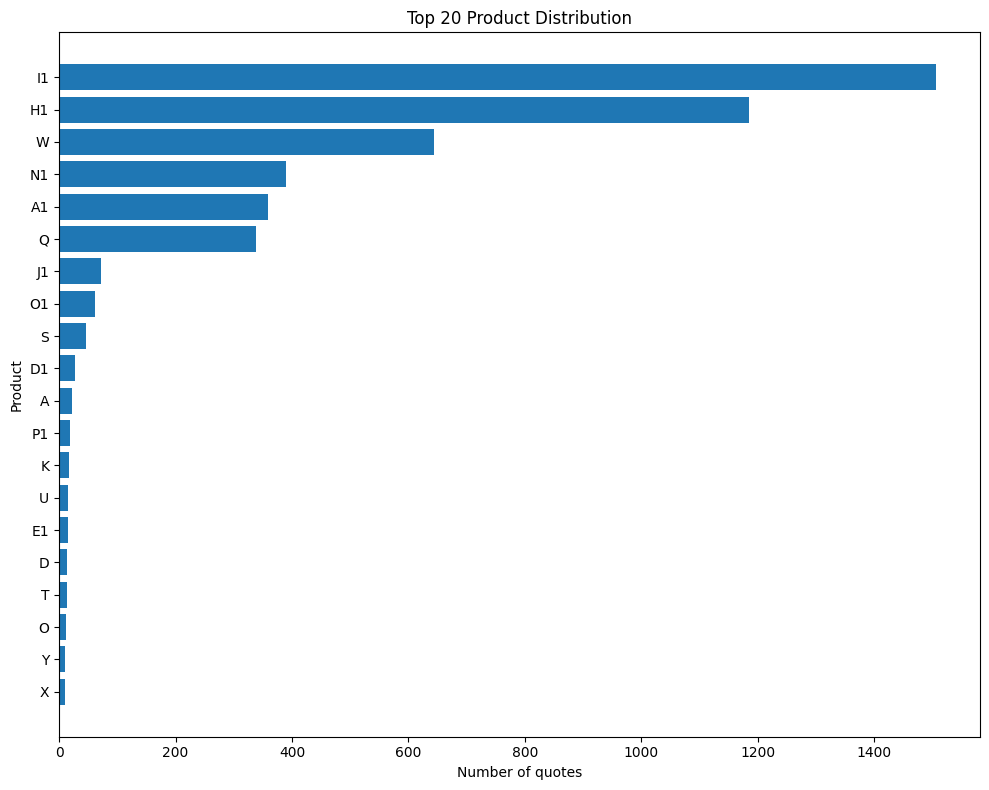

In [71]:
plt.figure(figsize=(10, 8))

plt.barh(
    product_dist.head(20)["product"],
    product_dist.head(20)["count"]
)

plt.gca().invert_yaxis()
plt.xlabel("Number of quotes")
plt.ylabel("Product")
plt.title("Top 20 Product Distribution")
plt.tight_layout()
plt.show()

In [72]:
min_product_count = 15

product_counts = df_model["product"].value_counts()

rare_products = product_counts[
    product_counts < min_product_count
].index

df_model["product_model"] = df_model["product"].replace(
    rare_products,
    "Other"
)

df_model["product_model"].value_counts()

product_model
I1       1506
H1       1184
W         644
N1        390
A1        358
Q         339
Other     194
J1         72
O1         62
S          46
D1         28
A          23
P1         19
K          17
U          16
E1         15
Name: count, dtype: int64

## HistGradientBoostingClassifier

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)

In [74]:
categorical_features = ["product_model"]
numeric_features = [col for col in features if col not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
                encoded_missing_value=-1
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

In [75]:
df_model["stratify_label"] = (
    df_model["product_model"].astype(str)
    + "_"
    + df_model["success"].astype(str)
)

stratify_counts = df_model["stratify_label"].value_counts()

rare_stratify_labels = stratify_counts[
    stratify_counts < 2
].index

df_model["stratify_label_safe"] = df_model["stratify_label"].where(
    ~df_model["stratify_label"].isin(rare_stratify_labels),
    df_model["success"].astype(str)
)

In [76]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_model["stratify_label_safe"]
)

In [77]:
hgb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ))
])

hgb_model.fit(X_train, y_train)

y_pred = hgb_model.predict(X_test)
y_prob = hgb_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("PR AUC:", average_precision_score(y_test, y_prob))
print("Log Loss:", log_loss(y_test, y_prob))
print("Brier Score:", brier_score_loss(y_test, y_prob))

Confusion Matrix:
[[728  17]
 [ 62 176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       745
           1       0.91      0.74      0.82       238

    accuracy                           0.92       983
   macro avg       0.92      0.86      0.88       983
weighted avg       0.92      0.92      0.92       983

ROC AUC: 0.9466104562630422
PR AUC: 0.9003918771551851
Log Loss: 0.23243058440847544
Brier Score: 0.0645511134177323


In [78]:
df_model["predicted_win_probability"] = hgb_model.predict_proba(
    df_model[features]
)[:, 1]

df_model["predicted_win_probability_pct"] = (
    df_model["predicted_win_probability"] * 100
).round(2)

df_model[
    [
        "quote_id",
        "product",
        "product_model",
        "gross_margin_rate",
        "unit_price",
        "success",
        "predicted_win_probability_pct"
    ]
].head(10)

,quote_id,product,product_model,gross_margin_rate,unit_price,success,predicted_win_probability_pct
0,Q-00114,W,W,0.0712,136000.0,1,97.27
1,Q-00119,H1,H1,0.3079,290000.0,1,99.97
2,Q-00161,Y,Other,0.4224,2379000.0,0,2.90
3,Q-00167,O1,O1,0.4117,775970.0,1,90.99
4,Q-00214,I1,I1,0.6787,300000.0,1,96.23
5,Q-00473,H1,H1,0.5475,400000.0,1,86.72
6,Q-00517,I1,I1,0.2949,228964.0,1,91.54
7,Q-00521,N1,N1,0.6515,1283500.0,0,0.01
8,Q-00525,H1,H1,0.3983,290000.0,1,99.98
9,Q-00525,I1,I1,0.3983,270000.0,1,65.53


In [79]:
y_prob = hgb_model.predict_proba(X_test)[:, 1]
y_prob

array([9.99978545e-01, 8.55794240e-01, 2.41460739e-02, 2.68475468e-03,
       6.96760242e-02, 9.99325514e-01, 2.27263842e-02, 1.86363221e-03,
       4.37877429e-04, 9.28154711e-01, 6.50770798e-02, 7.15328413e-03,
       9.70644784e-01, 1.53270352e-01, 1.19531738e-02, 7.40123127e-03,
       6.90714216e-03, 1.31778220e-02, 7.40123127e-03, 9.99892065e-01,
       5.37755539e-02, 1.84785577e-01, 3.07441383e-02, 2.74683652e-01,
       1.23917987e-02, 1.10901243e-01, 6.59745474e-05, 9.99688836e-01,
       1.99541911e-01, 3.33763558e-01, 9.99853360e-01, 9.99965104e-01,
       7.40123127e-03, 1.09088270e-01, 9.99944140e-01, 1.37601743e-04,
       8.04476578e-02, 1.67547711e-02, 1.37601743e-04, 4.87009594e-02,
       3.80730260e-02, 3.68015043e-03, 5.33284841e-03, 7.15328413e-03,
       4.17167394e-03, 1.32238445e-02, 8.91634953e-01, 7.47953466e-01,
       5.04914565e-02, 7.15328413e-03, 7.98472051e-01, 9.99665210e-01,
       6.55929036e-03, 3.10942204e-02, 5.04914565e-02, 5.58086487e-03,
      

## CatBoost

In [80]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, log_loss, brier_score_loss

df_cat = df_model.copy()

X = df_cat[features]
y = df_cat[target]

cat_features = ["product_model"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_cat["stratify_label_safe"]
)

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    auto_class_weights="Balanced"
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

y_pred_cat = cat_model.predict(X_test)
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_cat))
print(classification_report(y_test, y_pred_cat))
print("ROC AUC:", roc_auc_score(y_test, y_prob_cat))
print("Log Loss:", log_loss(y_test, y_prob_cat))
print("Brier Score:", brier_score_loss(y_test, y_prob_cat))

0:	test: 0.8571598	best: 0.8571598 (0)	total: 66.2ms	remaining: 33.1s
100:	test: 0.9173538	best: 0.9173538 (100)	total: 6.17s	remaining: 24.4s
200:	test: 0.9283374	best: 0.9284953 (199)	total: 12.2s	remaining: 18.2s
300:	test: 0.9382240	best: 0.9382240 (300)	total: 18.1s	remaining: 12s
400:	test: 0.9414331	best: 0.9418392 (374)	total: 23.9s	remaining: 5.89s
499:	test: 0.9423749	best: 0.9427246 (493)	total: 29.5s	remaining: 0us

bestTest = 0.9427246066
bestIteration = 493

Shrink model to first 494 iterations.
[[706  39]
 [ 53 185]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       745
           1       0.83      0.78      0.80       238

    accuracy                           0.91       983
   macro avg       0.88      0.86      0.87       983
weighted avg       0.90      0.91      0.91       983

ROC AUC: 0.9427246066211721
Log Loss: 0.250767747810248
Brier Score: 0.07382327646022262


In [81]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": cat_model.get_feature_importance()
}).sort_values("importance", ascending=False)

feature_importance.head(20)

,feature,importance
26,estimated_cost,17.980556
5,gross_margin_rate,12.719777
25,grant_ratio_to_subtotal,8.952858
23,is_lower_than_competitor,6.751393
27,estimated_gross_profit,5.908309
24,effective_price_after_grant,5.665974
2,unit_price,4.912050
18,price_gap_avg_competitor,4.535517
0,product_model,4.530052
4,subtotal_price,4.187378


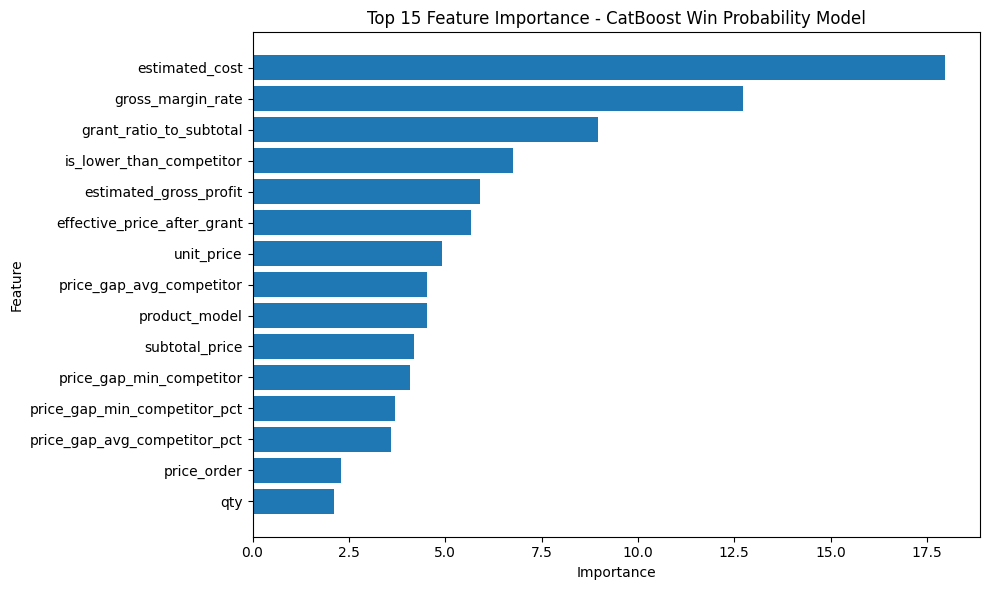

In [82]:
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance.head(15)["feature"],
    feature_importance.head(15)["importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - CatBoost Win Probability Model")
plt.tight_layout()
plt.show()

In [83]:
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]
y_prob_cat

array([0.99925569, 0.88886168, 0.06011999, 0.01953059, 0.24301589,
       0.98742733, 0.0565697 , 0.01315376, 0.00792729, 0.76559639,
       0.27745975, 0.06593931, 0.98671828, 0.5792676 , 0.04877341,
       0.03272057, 0.08436082, 0.07727866, 0.03272057, 0.99908152,
       0.19142491, 0.67440315, 0.25288821, 0.5750858 , 0.0921562 ,
       0.16039781, 0.00207875, 0.98668659, 0.47678602, 0.62317808,
       0.99108461, 0.99947881, 0.03272057, 0.53370778, 0.99948073,
       0.00337443, 0.40812859, 0.07880353, 0.00337443, 0.13962427,
       0.0678501 , 0.04015231, 0.11347412, 0.06593931, 0.06632424,
       0.11548858, 0.78631741, 0.64754801, 0.09769162, 0.06593931,
       0.58904611, 0.99901034, 0.03177092, 0.06925041, 0.09769162,
       0.06801083, 0.04129568, 0.11347412, 0.03272057, 0.03177092,
       0.38781699, 0.01936337, 0.41736812, 0.11439135, 0.00792729,
       0.97739085, 0.08223953, 0.01936337, 0.99749412, 0.01315376,
       0.00792729, 0.13605761, 0.12555257, 0.04015231, 0.19142

## Rekomendasi GMR

In [84]:
import numpy as np
import pandas as pd

gmr_grid = np.arange(-0.20, 0.65, 0.05)

def recommend_gmr_for_quote(row, model, features, gmr_grid):
    scenarios = []

    # estimasi cost per unit dari kondisi existing
    estimated_unit_cost = row["unit_price"] * (1 - row["gross_margin_rate"])

    for new_gmr in gmr_grid:
        # hindari pembagian tidak valid
        if new_gmr >= 1:
            continue

        scenario = row.copy()

        # update GMR
        scenario["gross_margin_rate"] = new_gmr

        # update price berdasarkan GMR baru
        new_unit_price = estimated_unit_cost / (1 - new_gmr)
        new_subtotal_price = new_unit_price * row["qty"]

        scenario["unit_price"] = new_unit_price
        scenario["subtotal_price"] = new_subtotal_price

        # update profit-related features
        scenario["estimated_cost"] = estimated_unit_cost * row["qty"]
        scenario["estimated_gross_profit"] = new_subtotal_price * new_gmr

        # update grant-related features
        scenario["effective_price_after_grant"] = (
            new_subtotal_price - row["energy_grant_amount"]
        )

        if new_subtotal_price != 0:
            scenario["grant_ratio_to_subtotal"] = (
                row["energy_grant_amount"] / new_subtotal_price
            )
        else:
            scenario["grant_ratio_to_subtotal"] = np.nan

        # update competitor gap kalau competitor price tersedia
        if pd.notna(row.get("avg_competitor_price", np.nan)):
            scenario["price_gap_avg_competitor"] = (
                new_unit_price - row["avg_competitor_price"]
            )
            scenario["price_gap_avg_competitor_pct"] = (
                scenario["price_gap_avg_competitor"] / row["avg_competitor_price"]
            ) * 100
            scenario["higher_than_avg_competitor"] = int(
                new_unit_price > row["avg_competitor_price"]
            )
        else:
            scenario["price_gap_avg_competitor"] = np.nan
            scenario["price_gap_avg_competitor_pct"] = np.nan
            scenario["higher_than_avg_competitor"] = 0

        if pd.notna(row.get("min_competitor_price", np.nan)):
            scenario["price_gap_min_competitor"] = (
                new_unit_price - row["min_competitor_price"]
            )
            scenario["price_gap_min_competitor_pct"] = (
                scenario["price_gap_min_competitor"] / row["min_competitor_price"]
            ) * 100
            scenario["is_lower_than_competitor"] = int(
                new_unit_price < row["min_competitor_price"]
            )
        else:
            scenario["price_gap_min_competitor"] = np.nan
            scenario["price_gap_min_competitor_pct"] = np.nan
            scenario["is_lower_than_competitor"] = 0

        scenarios.append(scenario)

    scenarios_df = pd.DataFrame(scenarios)

    # prediksi probability
    X_scenarios = scenarios_df[features]
    scenarios_df["predicted_win_probability"] = (
        model.predict_proba(X_scenarios)[:, 1]
    )

    # expected profit
    scenarios_df["predicted_expected_profit"] = (
        scenarios_df["predicted_win_probability"] *
        scenarios_df["estimated_gross_profit"]
    )

    return scenarios_df

In [85]:
def get_best_gmr_recommendation(row, model, features, gmr_grid, min_win_probability=0.30):
    scenarios_df = recommend_gmr_for_quote(
        row=row,
        model=model,
        features=features,
        gmr_grid=gmr_grid
    )

    valid_scenarios = scenarios_df[
        scenarios_df["predicted_win_probability"] >= min_win_probability
    ].copy()

    if len(valid_scenarios) == 0:
        best = scenarios_df.sort_values(
            "predicted_win_probability",
            ascending=False
        ).head(1)
    else:
        best = valid_scenarios.sort_values(
            "predicted_expected_profit",
            ascending=False
        ).head(1)

    return best

In [86]:
min_win_probability = 0.30

In [87]:
sample_row = df_model.iloc[0]

recommendation = get_best_gmr_recommendation(
    row=sample_row,
    model=hgb_model,
    features=features,
    gmr_grid=gmr_grid,
    min_win_probability=0.30
)

recommendation[
    [
        "quote_id",
        "product_model",
        "gross_margin_rate",
        "unit_price",
        "subtotal_price",
        "estimated_gross_profit",
        "predicted_win_probability",
        "predicted_expected_profit"
    ]
]

,quote_id,product_model,gross_margin_rate,unit_price,subtotal_price,estimated_gross_profit,predicted_win_probability,predicted_expected_profit
0,Q-00114,W,0.5,252633.6,252633.6,126316.8,0.915424,115633.436644


In [88]:
recommendation_list = []

for idx, row in df_model.iterrows():
    best = get_best_gmr_recommendation(
        row=row,
        model=hgb_model,
        features=features,
        gmr_grid=gmr_grid,
        min_win_probability=0.30
    )

    recommendation_list.append(best)

gmr_recommendations = pd.concat(recommendation_list, ignore_index=True)

In [89]:
gmr_recommendations["recommended_gmr_pct"] = (
    gmr_recommendations["gross_margin_rate"] * 100
).round(2)

gmr_recommendations["recommended_win_probability_pct"] = (
    gmr_recommendations["predicted_win_probability"] * 100
).round(2)

gmr_recommendations["recommended_unit_price"] = (
    gmr_recommendations["unit_price"].round(2)
)

gmr_recommendations["recommended_expected_profit"] = (
    gmr_recommendations["predicted_expected_profit"].round(2)
)

gmr_recommendations[
    [
        "quote_id",
        "product_model",
        "recommended_gmr_pct",
        "recommended_unit_price",
        "recommended_win_probability_pct",
        "estimated_gross_profit",
        "recommended_expected_profit"
    ]
].head(20)

,quote_id,product_model,recommended_gmr_pct,recommended_unit_price,recommended_win_probability_pct,estimated_gross_profit,recommended_expected_profit
0,Q-00114,W,50.0,252633.60,91.54,1.263168e+05,115633.44
1,Q-00119,H1,55.0,446020.00,96.10,4.906220e+05,471501.23
2,Q-00161,Other,45.0,2498382.55,31.67,1.124272e+06,356087.08
3,Q-00167,O1,45.0,830005.73,97.25,3.735026e+05,363228.23
4,Q-00214,I1,55.0,214200.00,99.24,1.178100e+05,116915.67
5,Q-00473,H1,60.0,452500.00,98.58,2.715000e+05,267636.82
6,Q-00517,I1,50.0,322885.03,81.58,1.614425e+05,131708.35
7,Q-00521,N1,50.0,894599.50,47.65,4.472997e+05,213145.86
8,Q-00525,H1,60.0,436232.50,95.48,5.234790e+05,499804.61
9,Q-00525,I1,50.0,324918.00,98.31,1.624590e+05,159719.56


# 6. Market Basket Analysis

In [90]:
import pandas as pd
import numpy as np

df_basket = df.copy()

# Drop duplicate quote_id + product dengan unit_price berbeda
# Keep only highest unit price based on is_highest_price
price_variation = (
    df_basket
    .groupby(["quote_id", "product"])["unit_price"]
    .transform("nunique")
)

df_basket = df_basket[
    (price_variation == 1) |
    ((price_variation > 1) & (df_basket["is_highest_price"] == 1))
].copy()

print("Before cleaning:", len(df))
print("After cleaning :", len(df_basket))
print("Dropped        :", len(df) - len(df_basket))

Before cleaning: 4991
After cleaning : 4913
Dropped        : 78


In [91]:
df_basket = df_basket.drop_duplicates(
    subset=["quote_id", "product"]
).copy()

In [92]:
basket_size = (
    df_basket
    .groupby("quote_id")["product"]
    .nunique()
    .reset_index(name="basket_size")
)

basket_size["basket_size"].value_counts().sort_index()

basket_size
1    4523
2     110
3       7
Name: count, dtype: int64

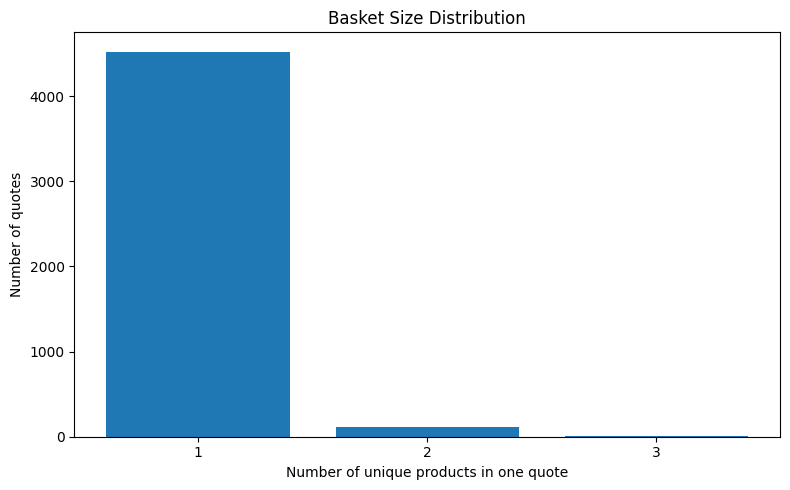

In [93]:
import matplotlib.pyplot as plt

basket_size_dist = basket_size["basket_size"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(basket_size_dist.index.astype(str), basket_size_dist.values)
plt.xlabel("Number of unique products in one quote")
plt.ylabel("Number of quotes")
plt.title("Basket Size Distribution")
plt.tight_layout()
plt.show()

In [94]:
basket_matrix = (
    df_basket
    .assign(value=1)
    .pivot_table(
        index="quote_id",
        columns="product",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

basket_matrix = basket_matrix.astype(bool)

basket_matrix.head()

product,A,A1,B,B1,C,C1,D,D1,E,E1,...,Q1,R,S,T,U,V,W,X,Y,Z
quote_id,,,,,,,,,,,,,,,,,,,,,
Q-00114,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
Q-00119,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Q-00161,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
Q-00167,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Q-00214,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Frequent itemset

In [95]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    basket_matrix,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    "support",
    ascending=False
)

frequent_itemsets.head(20)

,support,itemsets
2,0.312284,(I1)
1,0.242888,(H1)
7,0.135991,(W)
4,0.082328,(N1)
0,0.077155,(A1)
6,0.073060,(Q)
3,0.015517,(J1)
5,0.013362,(O1)


In [96]:
frequent_itemsets = apriori(
    basket_matrix,
    min_support=0.001,
    use_colnames=True
)

In [97]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.2
)

rules = rules.sort_values(
    ["lift", "confidence"],
    ascending=False
)

rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [98]:
rules_display = rules.copy()

rules_display["antecedents"] = rules_display["antecedents"].apply(
    lambda x: ", ".join(list(x))
)

rules_display["consequents"] = rules_display["consequents"].apply(
    lambda x: ", ".join(list(x))
)

rules_display[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

,antecedents,consequents,support,confidence,lift


In [99]:
quote_success = (
    df_basket
    .groupby("quote_id")["convert_to_order"]
    .first()
    .reset_index()
)

quote_success["success"] = (
    quote_success["convert_to_order"] == 0
).astype(int)

In [100]:
quote_level = basket_size.merge(
    quote_success[["quote_id", "success"]],
    on="quote_id",
    how="left"
)

quote_level.head()

,quote_id,basket_size,success
0,Q-00114,1,1
1,Q-00119,1,1
2,Q-00161,1,0
3,Q-00167,1,1
4,Q-00214,1,1


In [101]:
quote_level["basket_type"] = np.where(
    quote_level["basket_size"] == 1,
    "Single-product quote",
    "Multi-product quote"
)

basket_win_rate = (
    quote_level
    .groupby("basket_type")
    .agg(
        total_quotes=("quote_id", "count"),
        win_rate=("success", "mean"),
        avg_basket_size=("basket_size", "mean")
    )
    .reset_index()
)

basket_win_rate["win_rate_pct"] = (
    basket_win_rate["win_rate"] * 100
).round(2)

basket_win_rate

,basket_type,total_quotes,win_rate,avg_basket_size,win_rate_pct
0,Multi-product quote,117,0.393162,2.059829,39.32
1,Single-product quote,4523,0.212470,1.000000,21.25


In [102]:
def itemset_to_mask(basket_matrix, itemset):
    itemset = list(itemset)
    return basket_matrix[itemset].all(axis=1)

itemset_performance = []

for _, row in frequent_itemsets.iterrows():
    itemset = row["itemsets"]
    mask = itemset_to_mask(basket_matrix, itemset)

    quote_ids = basket_matrix[mask].index

    temp = quote_success[
        quote_success["quote_id"].isin(quote_ids)
    ]

    itemset_performance.append({
        "itemset": ", ".join(list(itemset)),
        "support": row["support"],
        "total_quotes": len(temp),
        "win_rate": temp["success"].mean()
    })

itemset_performance = pd.DataFrame(itemset_performance)

itemset_performance["win_rate_pct"] = (
    itemset_performance["win_rate"] * 100
).round(2)

itemset_performance = itemset_performance.sort_values(
    ["total_quotes", "win_rate"],
    ascending=False
)

itemset_performance.head(20)

,itemset,support,total_quotes,win_rate,win_rate_pct
12,I1,0.312284,1449,0.200138,20.01
10,H1,0.242888,1127,0.259095,25.91
30,W,0.135991,631,0.126783,12.68
19,N1,0.082328,382,0.340314,34.03
1,A1,0.077155,358,0.189944,18.99
23,Q,0.073060,339,0.103245,10.32
14,J1,0.015517,72,0.222222,22.22
21,O1,0.013362,62,0.467742,46.77
26,S,0.009914,46,0.152174,15.22
35,"H1, I1",0.007543,35,0.371429,37.14


In [103]:
itemset_performance_2plus = itemset_performance[
    itemset_performance["itemset"].str.contains(",")
].copy()

itemset_performance_2plus.sort_values(
    ["win_rate", "total_quotes"],
    ascending=False
).head(20)

,itemset,support,total_quotes,win_rate,win_rate_pct
35,"H1, I1",0.007543,35,0.371429,37.14
34,"I1, A1",0.002155,10,0.300000,30.00
36,"H1, N1",0.003233,15,0.200000,20.00


In [104]:
quote_profit = (
    df_basket
    .groupby("quote_id")
    .agg(
        quote_total_subtotal=("subtotal_price", "sum"),
        quote_total_profit=("estimated_gross_profit", "sum"),
        quote_avg_gmr=("gross_margin_rate", "mean")
    )
    .reset_index()
)

quote_level_full = (
    quote_level
    .merge(quote_profit, on="quote_id", how="left")
)

quote_level_full.head()

,quote_id,basket_size,success,basket_type,quote_total_subtotal,quote_total_profit,quote_avg_gmr
0,Q-00114,1,1,Single-product quote,136000.0,9683.200,0.0712
1,Q-00119,1,1,Single-product quote,580000.0,178582.000,0.3079
2,Q-00161,1,0,Single-product quote,2379000.0,1004889.600,0.4224
3,Q-00167,1,1,Single-product quote,775970.0,319466.849,0.4117
4,Q-00214,1,1,Single-product quote,300000.0,203610.000,0.6787


In [105]:
itemset_business_performance = []

for _, row in frequent_itemsets.iterrows():
    itemset = row["itemsets"]
    mask = itemset_to_mask(basket_matrix, itemset)

    quote_ids = basket_matrix[mask].index

    temp = quote_level_full[
        quote_level_full["quote_id"].isin(quote_ids)
    ]

    itemset_business_performance.append({
        "itemset": ", ".join(list(itemset)),
        "support": row["support"],
        "total_quotes": len(temp),
        "win_rate": temp["success"].mean(),
        "avg_quote_subtotal": temp["quote_total_subtotal"].mean(),
        "avg_quote_profit": temp["quote_total_profit"].mean(),
        "avg_quote_gmr": temp["quote_avg_gmr"].mean()
    })

itemset_business_performance = pd.DataFrame(itemset_business_performance)

itemset_business_performance["win_rate_pct"] = (
    itemset_business_performance["win_rate"] * 100
).round(2)

itemset_business_performance.sort_values(
    ["win_rate", "avg_quote_profit"],
    ascending=False
).head(20)

,itemset,support,total_quotes,win_rate,avg_quote_subtotal,avg_quote_profit,avg_quote_gmr,win_rate_pct
9,G,0.001509,7,1.000000,3.936686e+06,1.009011e+06,0.222643,100.00
4,C1,0.001078,5,1.000000,2.300647e+06,6.763311e+05,0.277660,100.00
11,I,0.001509,7,0.714286,3.188914e+06,8.120931e+05,0.242043,71.43
18,N,0.002155,10,0.700000,1.936271e+06,8.389742e+05,0.321940,70.00
29,V,0.001078,5,0.600000,1.994074e+06,1.034075e+06,0.468640,60.00
3,C,0.002155,10,0.600000,2.767450e+06,8.988017e+05,0.245200,60.00
24,Q1,0.002155,10,0.600000,1.890528e+06,5.729527e+05,0.291160,60.00
20,O,0.002586,12,0.500000,3.005765e+06,1.486283e+06,0.405192,50.00
31,X,0.002155,10,0.500000,2.965709e+05,4.227212e+04,0.222100,50.00
21,O1,0.013362,62,0.467742,9.826347e+05,3.898962e+05,0.378132,46.77


## versi 2

Before cleaning: 4991
After cleaning : 4764
Dropped        : 227

Basket size distribution:


,basket_size,total_quotes,percentage
0,1,4523,97.48
1,2,110,2.37
2,3,7,0.15



All basket matrix shape: (4640, 43)
Total all quotes          : 4640
Total multi-product quotes: 117
Multi-product quote ratio : 2.52 %

Minimum count threshold: 5
Minimum conditional support: 0.0427

Frequent itemsets among multi-product quotes:


,itemsets_display,itemset_size,support,support_count
2,H1,1,0.487179,57
3,I1,1,0.427350,50
5,N1,1,0.213675,25
0,A1,1,0.153846,18
8,Q,1,0.111111,13
10,W,1,0.059829,7
6,O,1,0.051282,6
7,O1,1,0.051282,6
1,E1,1,0.042735,5
4,J1,1,0.042735,5



Frequent product combinations among multi-product quotes:


,itemsets_display,itemset_size,support,support_count
12,"H1, I1",2,0.299145,35
13,"H1, N1",2,0.128205,15
11,"A1, I1",2,0.085470,10



Association rules among multi-product quotes:


,antecedents_display,consequents_display,support,support_count,confidence,lift
1,I1,H1,0.299145,35,0.700000,1.436842
0,H1,I1,0.299145,35,0.614035,1.436842
2,N1,H1,0.128205,15,0.600000,1.231579
3,H1,N1,0.128205,15,0.263158,1.231579
5,A1,I1,0.085470,10,0.555556,1.300000
4,I1,A1,0.085470,10,0.200000,1.300000



Business performance of frequent product combinations:


,itemset,itemset_size,conditional_support_pct,support_count,win_rate_pct,avg_quote_gmr_pct,avg_quote_subtotal,avg_quote_profit
0,"H1, I1",2,29.91,35,37.14,43.67,9.021610e+05,374926.554621
1,"H1, N1",2,12.82,15,20.00,43.06,1.659086e+06,790356.139565
2,"A1, I1",2,8.55,10,30.00,44.40,7.023399e+05,316643.914579


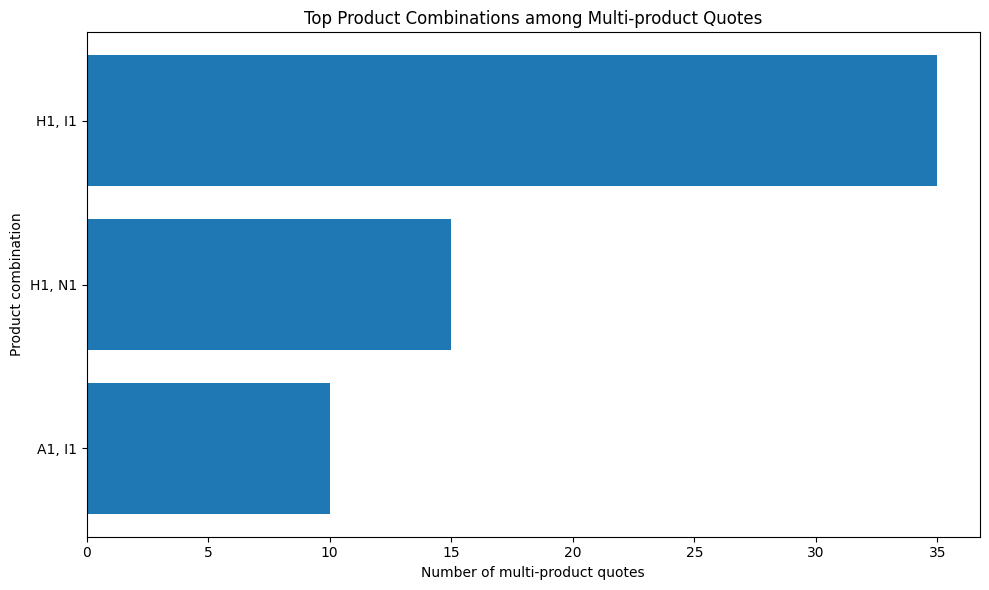


Interpretation note:
In this conditional analysis, support is calculated only among quotes that contain at least two products. Therefore, it should be interpreted as the proportion of multi-product quotes containing a product combination, not as the proportion of all quotes.


In [106]:
# ============================================================
# CONDITIONAL MARKET BASKET ANALYSIS
# Support is calculated only among multi-product quotes
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori, association_rules


# ============================================================
# 1. Prepare clean basket dataset
#    Rule: if same quote_id + product has different unit_price,
#    keep only the row with the highest unit price.
# ============================================================

df_basket_cond = df.copy()

price_variation = (
    df_basket_cond
    .groupby(["quote_id", "product"])["unit_price"]
    .transform("nunique")
)

df_basket_cond = df_basket_cond[
    (price_variation == 1) |
    ((price_variation > 1) & (df_basket_cond["is_highest_price"] == 1))
].copy()

# For market basket, each product should appear once per quote
df_basket_cond = df_basket_cond.drop_duplicates(
    subset=["quote_id", "product"]
).copy()

print("Before cleaning:", len(df))
print("After cleaning :", len(df_basket_cond))
print("Dropped        :", len(df) - len(df_basket_cond))


# ============================================================
# 2. Create quote-level basket size
# ============================================================

basket_size_cond = (
    df_basket_cond
    .groupby("quote_id")["product"]
    .nunique()
    .reset_index(name="basket_size")
)

basket_size_summary_cond = (
    basket_size_cond["basket_size"]
    .value_counts()
    .sort_index()
    .reset_index()
)

basket_size_summary_cond.columns = ["basket_size", "total_quotes"]

basket_size_summary_cond["percentage"] = (
    basket_size_summary_cond["total_quotes"] /
    basket_size_summary_cond["total_quotes"].sum() * 100
).round(2)

print("\nBasket size distribution:")
display(basket_size_summary_cond)


# ============================================================
# 3. Create basket matrix for all quotes
# ============================================================

basket_matrix_all = (
    df_basket_cond
    .assign(value=1)
    .pivot_table(
        index="quote_id",
        columns="product",
        values="value",
        aggfunc="max",
        fill_value=0
    )
)

basket_matrix_all = basket_matrix_all.astype(bool)

print("\nAll basket matrix shape:", basket_matrix_all.shape)


# ============================================================
# 4. Filter only multi-product quotes
#    This changes the denominator of support.
# ============================================================

multi_quote_ids = basket_size_cond.loc[
    basket_size_cond["basket_size"] >= 2,
    "quote_id"
]

basket_matrix_multi = basket_matrix_all.loc[multi_quote_ids].copy()

print("Total all quotes          :", basket_matrix_all.shape[0])
print("Total multi-product quotes:", basket_matrix_multi.shape[0])
print(
    "Multi-product quote ratio :",
    round(basket_matrix_multi.shape[0] / basket_matrix_all.shape[0] * 100, 2),
    "%"
)


# ============================================================
# 5. Frequent itemsets among multi-product quotes
#    Here, support = count(itemset) / number of multi-product quotes
# ============================================================

min_count = 5

if basket_matrix_multi.shape[0] == 0:
    print("\nNo multi-product quotes found. Conditional basket analysis cannot be performed.")

else:
    min_support_multi = min_count / basket_matrix_multi.shape[0]

    frequent_itemsets_multi = apriori(
        basket_matrix_multi,
        min_support=min_support_multi,
        use_colnames=True
    )

    frequent_itemsets_multi["support_count"] = (
        frequent_itemsets_multi["support"] *
        basket_matrix_multi.shape[0]
    ).round().astype(int)

    frequent_itemsets_multi["itemset_size"] = frequent_itemsets_multi["itemsets"].apply(len)

    frequent_itemsets_multi["itemsets_display"] = (
        frequent_itemsets_multi["itemsets"]
        .apply(lambda x: ", ".join(sorted(list(x))))
    )

    frequent_itemsets_multi = frequent_itemsets_multi.sort_values(
        ["itemset_size", "support_count", "support"],
        ascending=[True, False, False]
    )

    print("\nMinimum count threshold:", min_count)
    print("Minimum conditional support:", round(min_support_multi, 4))

    print("\nFrequent itemsets among multi-product quotes:")
    display(
        frequent_itemsets_multi[
            [
                "itemsets_display",
                "itemset_size",
                "support",
                "support_count"
            ]
        ]
    )


# ============================================================
# 6. Show only product combinations with at least 2 products
# ============================================================

if basket_matrix_multi.shape[0] > 0 and len(frequent_itemsets_multi) > 0:

    frequent_itemsets_multi_2plus = frequent_itemsets_multi[
        frequent_itemsets_multi["itemset_size"] >= 2
    ].copy()

    print("\nFrequent product combinations among multi-product quotes:")
    display(
        frequent_itemsets_multi_2plus[
            [
                "itemsets_display",
                "itemset_size",
                "support",
                "support_count"
            ]
        ].sort_values(
            ["support_count", "support"],
            ascending=False
        )
    )


# ============================================================
# 7. Association rules among multi-product quotes
#    Confidence and lift are also calculated within the
#    multi-product quote subset.
# ============================================================

if (
    basket_matrix_multi.shape[0] > 0
    and len(frequent_itemsets_multi) > 0
    and frequent_itemsets_multi["itemset_size"].max() >= 2
):

    rules_multi = association_rules(
        frequent_itemsets_multi,
        metric="confidence",
        min_threshold=0.2
    )

    if len(rules_multi) == 0:
        print("\nNo association rules generated under the current threshold.")

    else:
        rules_multi["support_count"] = (
            rules_multi["support"] *
            basket_matrix_multi.shape[0]
        ).round().astype(int)

        rules_multi["antecedents_display"] = (
            rules_multi["antecedents"]
            .apply(lambda x: ", ".join(sorted(list(x))))
        )

        rules_multi["consequents_display"] = (
            rules_multi["consequents"]
            .apply(lambda x: ", ".join(sorted(list(x))))
        )

        rules_multi = rules_multi.sort_values(
            ["support_count", "lift", "confidence"],
            ascending=[False, False, False]
        )

        print("\nAssociation rules among multi-product quotes:")
        display(
            rules_multi[
                [
                    "antecedents_display",
                    "consequents_display",
                    "support",
                    "support_count",
                    "confidence",
                    "lift"
                ]
            ]
        )


# ============================================================
# 8. Add quote-level success, profit, and GMR information
# ============================================================

quote_success_cond = (
    df_basket_cond
    .groupby("quote_id")["convert_to_order"]
    .first()
    .reset_index()
)

quote_success_cond["success"] = (
    quote_success_cond["convert_to_order"] == 0
).astype(int)

quote_business_cond = (
    df_basket_cond
    .groupby("quote_id")
    .agg(
        quote_total_subtotal=("subtotal_price", "sum"),
        quote_total_profit=("estimated_gross_profit", "sum"),
        quote_avg_gmr=("gross_margin_rate", "mean")
    )
    .reset_index()
)

quote_level_cond = (
    basket_size_cond
    .merge(quote_success_cond[["quote_id", "success"]], on="quote_id", how="left")
    .merge(quote_business_cond, on="quote_id", how="left")
)

quote_level_multi = quote_level_cond[
    quote_level_cond["basket_size"] >= 2
].copy()


# ============================================================
# 9. Business performance of frequent product combinations
#    Denominator is multi-product quotes, but performance is
#    calculated from quote-level success and profit.
# ============================================================

if (
    basket_matrix_multi.shape[0] > 0
    and "frequent_itemsets_multi_2plus" in globals()
    and len(frequent_itemsets_multi_2plus) > 0
):

    itemset_business_multi = []

    for _, row in frequent_itemsets_multi_2plus.iterrows():
        itemset = list(row["itemsets"])

        mask = basket_matrix_multi[itemset].all(axis=1)
        quote_ids = basket_matrix_multi[mask].index

        temp = quote_level_multi[
            quote_level_multi["quote_id"].isin(quote_ids)
        ]

        itemset_business_multi.append({
            "itemset": ", ".join(sorted(itemset)),
            "itemset_size": len(itemset),
            "conditional_support": row["support"],
            "support_count": len(temp),
            "win_rate": temp["success"].mean(),
            "avg_quote_subtotal": temp["quote_total_subtotal"].mean(),
            "avg_quote_profit": temp["quote_total_profit"].mean(),
            "avg_quote_gmr": temp["quote_avg_gmr"].mean()
        })

    itemset_business_multi = pd.DataFrame(itemset_business_multi)

    itemset_business_multi["conditional_support_pct"] = (
        itemset_business_multi["conditional_support"] * 100
    ).round(2)

    itemset_business_multi["win_rate_pct"] = (
        itemset_business_multi["win_rate"] * 100
    ).round(2)

    itemset_business_multi["avg_quote_gmr_pct"] = (
        itemset_business_multi["avg_quote_gmr"] * 100
    ).round(2)

    itemset_business_multi = itemset_business_multi.sort_values(
        ["support_count", "win_rate", "avg_quote_profit"],
        ascending=[False, False, False]
    )

    print("\nBusiness performance of frequent product combinations:")
    display(
        itemset_business_multi[
            [
                "itemset",
                "itemset_size",
                "conditional_support_pct",
                "support_count",
                "win_rate_pct",
                "avg_quote_gmr_pct",
                "avg_quote_subtotal",
                "avg_quote_profit"
            ]
        ]
    )


# ============================================================
# 10. Visualization: top frequent product combinations
# ============================================================

if (
    "itemset_business_multi" in globals()
    and len(itemset_business_multi) > 0
):

    top_n = 10

    plot_data = itemset_business_multi.head(top_n).copy()

    plt.figure(figsize=(10, 6))

    plt.barh(
        plot_data["itemset"],
        plot_data["support_count"]
    )

    plt.gca().invert_yaxis()
    plt.xlabel("Number of multi-product quotes")
    plt.ylabel("Product combination")
    plt.title("Top Product Combinations among Multi-product Quotes")
    plt.tight_layout()
    plt.show()


# ============================================================
# 11. Interpretation helper
# ============================================================

print("\nInterpretation note:")
print(
    "In this conditional analysis, support is calculated only among quotes "
    "that contain at least two products. Therefore, it should be interpreted "
    "as the proportion of multi-product quotes containing a product combination, "
    "not as the proportion of all quotes."
)

# Lost tender diagnosis

Before cleaning: 4991
After cleaning : 4913
Dropped        : 78

Target distribution:


,count,count
0,Fail,3722
1,Success,1191



Thresholds used:
High GMR threshold, 75th percentile among failed quotes: 0.4983
Low grant ratio threshold, median overall: 0.3922
Overall win rate: 0.2424

Number of failed quote-product records: 3722

Lost tender diagnosis summary:


,reason,failed_quotes_count,failed_quotes_pct
1,Price higher than competitors,2702,72.60
3,Product has historically low win rate,2485,66.77
2,Low or no energy grant advantage,1991,53.49
0,Gross Margin Rate too high,980,26.33
4,No competitor information available,660,17.73


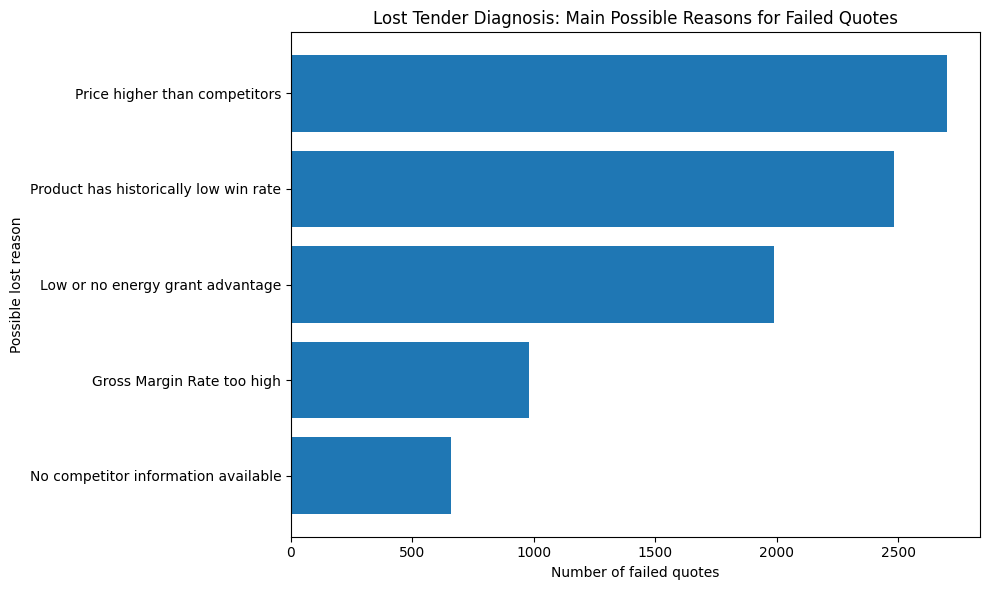


Product-level lost tender diagnosis:


,product,failed_quotes,avg_gmr,avg_product_win_rate,high_gmr_count,price_higher_count,low_or_no_grant_count,low_win_rate_product_count,no_competitor_info_count,avg_gmr_pct,avg_product_win_rate_pct
14,I1,1161,0.471173,0.229084,364,1156,347,1161,0,47.12,22.91
12,H1,836,0.518071,0.293919,268,742,254,0,0,51.81,29.39
35,W,555,0.242652,0.138199,54,0,515,555,555,24.27,13.82
28,Q,304,0.174595,0.103245,2,304,304,304,0,17.46,10.32
1,A1,290,0.404023,0.189944,99,290,228,290,0,40.40,18.99
23,N1,254,0.419910,0.348718,70,64,72,0,0,41.99,34.87
16,J1,56,0.406400,0.222222,30,35,56,56,0,40.64,22.22
31,S,39,0.506982,0.152174,19,26,39,39,0,50.70,15.22
25,O1,33,0.423482,0.467742,12,8,9,0,0,42.35,46.77
6,D1,22,0.459000,0.214286,7,22,22,22,0,45.90,21.43



Sample lost quote diagnosis table:


,quote_id,product,gross_margin_rate,unit_price,qty,subtotal_price,energy_grant_amount,grant_ratio_to_subtotal,product_win_rate_pct,num_diagnosis_reasons,lost_diagnosis_reasons,competitor_count_available,avg_competitor_price,price_gap_avg_competitor,price_gap_avg_competitor_pct,higher_than_avg_competitor,gross_margin_rate_pct,grant_ratio_to_subtotal_pct
2,Q-00161,Y,0.4224,2379000.0,1,2379000.0,720000,0.302648,27.27,2,Low or no energy grant advantage; No competito...,0,NaN,NaN,NaN,NaN,42.24,30.26
7,Q-00521,N1,0.6515,1283500.0,1,1283500.0,375000,0.292170,34.87,3,Gross Margin Rate too high; Price higher than ...,2,830000.0,453500.0,54.638554,1.0,65.15,29.22
12,Q-01291,K,0.4647,577800.0,1,577800.0,190920,0.330426,23.53,3,Low or no energy grant advantage; Product has ...,0,NaN,NaN,NaN,NaN,46.47,33.04
18,Q-01775,H1,0.4711,391300.0,2,782600.0,222000,0.283670,29.39,2,Price higher than competitors; Low or no energ...,1,360000.0,31300.0,8.694444,1.0,47.11,28.37
28,Q-02733,S,0.2164,1222400.0,3,3667200.0,528000,0.143979,15.22,2,Low or no energy grant advantage; Product has ...,1,1880000.0,-657600.0,-34.978723,0.0,21.64,14.40
36,Q-03409,N1,0.6487,1283500.0,1,1283500.0,375000,0.292170,34.87,3,Gross Margin Rate too high; Price higher than ...,2,830000.0,453500.0,54.638554,1.0,64.87,29.22
37,Q-03409,N1,0.6487,1283500.0,1,1283500.0,375000,0.292170,34.87,3,Gross Margin Rate too high; Price higher than ...,2,830000.0,453500.0,54.638554,1.0,64.87,29.22
74,Q-05576,M,0.5687,1252700.0,1,1252700.0,322500,0.257444,22.22,4,Gross Margin Rate too high; Low or no energy g...,0,NaN,NaN,NaN,NaN,56.87,25.74
75,Q-05577,E,0.5986,408100.0,1,408100.0,48600,0.119088,20.00,4,Gross Margin Rate too high; Low or no energy g...,0,NaN,NaN,NaN,NaN,59.86,11.91
76,Q-05577,E,0.5986,408100.0,1,408100.0,48600,0.119088,20.00,4,Gross Margin Rate too high; Low or no energy g...,0,NaN,NaN,NaN,NaN,59.86,11.91



Saved files:
- lost_tender_diagnosis_summary.csv
- lost_tender_product_summary.csv
- lost_quote_diagnosis_table.csv


In [107]:
# ============================================================
# LOST TENDER DIAGNOSIS
# Goal:
# Analyze why failed quotes may have lost.
#
# Possible reasons:
# 1. Gross Margin Rate too high
# 2. Price higher than competitors
# 3. Low or no energy grant advantage
# 4. Product has historically low win rate
# 5. No competitor information available
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Prepare clean dataset
#    Rule: if same quote_id + product has different unit_price,
#    keep only the row with the highest unit price.
# ============================================================

df_lost = df.copy()

price_variation = (
    df_lost
    .groupby(["quote_id", "product"])["unit_price"]
    .transform("nunique")
)

df_lost = df_lost[
    (price_variation == 1) |
    ((price_variation > 1) & (df_lost["is_highest_price"] == 1))
].copy()

print("Before cleaning:", len(df))
print("After cleaning :", len(df_lost))
print("Dropped        :", len(df) - len(df_lost))


# ============================================================
# 2. Create success / failure flag
#    Original:
#    convert_to_order = 0 means Success
#    convert_to_order = 1 means Fail
# ============================================================

df_lost["success"] = (df_lost["convert_to_order"] == 0).astype(int)
df_lost["failed"] = (df_lost["convert_to_order"] == 1).astype(int)

print("\nTarget distribution:")
display(
    df_lost["success"]
    .value_counts()
    .rename(index={1: "Success", 0: "Fail"})
    .reset_index()
    .rename(columns={"index": "status", "success": "count"})
)


# ============================================================
# 3. Define dynamic thresholds
#    These thresholds are data-driven, so they are easier to defend.
# ============================================================

# High GMR threshold:
# Use 75th percentile of GMR among failed quotes.
failed_quotes = df_lost[df_lost["failed"] == 1].copy()

high_gmr_threshold = failed_quotes["gross_margin_rate"].quantile(0.75)

# Low grant threshold:
# Use median grant ratio among all quotes with available grant ratio.
# If grant_ratio_to_subtotal is missing, create it.
if "grant_ratio_to_subtotal" not in df_lost.columns:
    df_lost["grant_ratio_to_subtotal"] = (
        df_lost["energy_grant_amount"] / df_lost["subtotal_price"]
    )

low_grant_threshold = df_lost["grant_ratio_to_subtotal"].median()

# Product low win rate threshold:
# Product is considered low-performing if its historical win rate
# is below the overall win rate.
overall_win_rate = df_lost["success"].mean()

product_performance = (
    df_lost
    .groupby("product")
    .agg(
        total_quotes=("quote_id", "count"),
        product_win_rate=("success", "mean")
    )
    .reset_index()
)

product_performance["product_win_rate_pct"] = (
    product_performance["product_win_rate"] * 100
).round(2)

product_performance["is_low_win_rate_product"] = (
    product_performance["product_win_rate"] < overall_win_rate
).astype(int)

df_lost = df_lost.merge(
    product_performance[
        [
            "product",
            "total_quotes",
            "product_win_rate",
            "product_win_rate_pct",
            "is_low_win_rate_product"
        ]
    ],
    on="product",
    how="left"
)

print("\nThresholds used:")
print("High GMR threshold, 75th percentile among failed quotes:", round(high_gmr_threshold, 4))
print("Low grant ratio threshold, median overall:", round(low_grant_threshold, 4))
print("Overall win rate:", round(overall_win_rate, 4))


# ============================================================
# 4. Create diagnosis flags
# ============================================================

# Reason 1: Gross Margin Rate too high
df_lost["reason_high_gmr"] = (
    df_lost["gross_margin_rate"] >= high_gmr_threshold
).astype(int)

# Reason 2: Price higher than competitors
# Use available engineered features if present.
# higher_than_avg_competitor = 1 means our price is higher than avg competitor.
if "higher_than_avg_competitor" in df_lost.columns:
    df_lost["reason_price_higher_than_competitor"] = (
        df_lost["higher_than_avg_competitor"] == 1
    ).astype(int)
else:
    df_lost["reason_price_higher_than_competitor"] = (
        df_lost["price_gap_avg_competitor"] > 0
    ).astype(int)

# Reason 3: Low or no energy grant advantage
df_lost["reason_low_or_no_grant"] = (
    (df_lost["energy_grant_amount"].fillna(0) <= 0) |
    (df_lost["grant_ratio_to_subtotal"].fillna(0) <= low_grant_threshold)
).astype(int)

# Reason 4: Product historically low win rate
df_lost["reason_low_win_rate_product"] = (
    df_lost["is_low_win_rate_product"] == 1
).astype(int)

# Reason 5: No competitor information available
# Use competitor_count_available if available.
if "competitor_count_available" in df_lost.columns:
    df_lost["reason_no_competitor_info"] = (
        df_lost["competitor_count_available"].fillna(0) == 0
    ).astype(int)
elif "known_num_compe" in df_lost.columns:
    df_lost["reason_no_competitor_info"] = (
        df_lost["known_num_compe"].fillna(0) == 0
    ).astype(int)
else:
    competitor_cols = ["competitor_a", "competitor_b", "competitor_c"]
    available_comp_cols = [col for col in competitor_cols if col in df_lost.columns]
    df_lost["reason_no_competitor_info"] = (
        df_lost[available_comp_cols].notna().sum(axis=1) == 0
    ).astype(int)


# ============================================================
# 5. Create readable diagnosis label for each failed quote
# ============================================================

reason_columns = [
    "reason_high_gmr",
    "reason_price_higher_than_competitor",
    "reason_low_or_no_grant",
    "reason_low_win_rate_product",
    "reason_no_competitor_info"
]

reason_label_map = {
    "reason_high_gmr": "Gross Margin Rate too high",
    "reason_price_higher_than_competitor": "Price higher than competitors",
    "reason_low_or_no_grant": "Low or no energy grant advantage",
    "reason_low_win_rate_product": "Product has historically low win rate",
    "reason_no_competitor_info": "No competitor information available"
}

def combine_reasons(row):
    reasons = [
        reason_label_map[col]
        for col in reason_columns
        if row[col] == 1
    ]
    if len(reasons) == 0:
        return "No clear rule-based reason"
    return "; ".join(reasons)

df_lost["lost_diagnosis_reasons"] = df_lost.apply(
    combine_reasons,
    axis=1
)

df_lost["num_diagnosis_reasons"] = df_lost[reason_columns].sum(axis=1)


# ============================================================
# 6. Focus only on failed quotes
# ============================================================

lost_quotes = df_lost[df_lost["failed"] == 1].copy()

print("\nNumber of failed quote-product records:", len(lost_quotes))


# ============================================================
# 7. Diagnosis summary: how common each reason is
# ============================================================

diagnosis_summary = []

for col in reason_columns:
    count = lost_quotes[col].sum()
    pct = count / len(lost_quotes) * 100 if len(lost_quotes) > 0 else 0

    diagnosis_summary.append({
        "reason": reason_label_map[col],
        "failed_quotes_count": int(count),
        "failed_quotes_pct": round(pct, 2)
    })

diagnosis_summary = pd.DataFrame(diagnosis_summary).sort_values(
    "failed_quotes_count",
    ascending=False
)

print("\nLost tender diagnosis summary:")
display(diagnosis_summary)


# ============================================================
# 8. Plot diagnosis summary
# ============================================================

plt.figure(figsize=(10, 6))

plt.barh(
    diagnosis_summary["reason"],
    diagnosis_summary["failed_quotes_count"]
)

plt.gca().invert_yaxis()
plt.xlabel("Number of failed quotes")
plt.ylabel("Possible lost reason")
plt.title("Lost Tender Diagnosis: Main Possible Reasons for Failed Quotes")
plt.tight_layout()
plt.show()


# ============================================================
# 9. Product-level lost diagnosis
#    Which products fail most often and why?
# ============================================================

product_lost_summary = (
    lost_quotes
    .groupby("product")
    .agg(
        failed_quotes=("quote_id", "count"),
        avg_gmr=("gross_margin_rate", "mean"),
        avg_product_win_rate=("product_win_rate", "mean"),
        high_gmr_count=("reason_high_gmr", "sum"),
        price_higher_count=("reason_price_higher_than_competitor", "sum"),
        low_or_no_grant_count=("reason_low_or_no_grant", "sum"),
        low_win_rate_product_count=("reason_low_win_rate_product", "sum"),
        no_competitor_info_count=("reason_no_competitor_info", "sum")
    )
    .reset_index()
)

product_lost_summary["avg_gmr_pct"] = (
    product_lost_summary["avg_gmr"] * 100
).round(2)

product_lost_summary["avg_product_win_rate_pct"] = (
    product_lost_summary["avg_product_win_rate"] * 100
).round(2)

product_lost_summary = product_lost_summary.sort_values(
    "failed_quotes",
    ascending=False
)

print("\nProduct-level lost tender diagnosis:")
display(product_lost_summary.head(20))


# ============================================================
# 10. Quote-level output for review
# ============================================================

quote_level_diagnosis_columns = [
    "quote_id",
    "product",
    "gross_margin_rate",
    "unit_price",
    "qty",
    "subtotal_price",
    "energy_grant_amount",
    "grant_ratio_to_subtotal",
    "product_win_rate_pct",
    "num_diagnosis_reasons",
    "lost_diagnosis_reasons"
]

optional_cols = [
    "competitor_count_available",
    "avg_competitor_price",
    "price_gap_avg_competitor",
    "price_gap_avg_competitor_pct",
    "higher_than_avg_competitor"
]

quote_level_diagnosis_columns += [
    col for col in optional_cols if col in lost_quotes.columns
]

lost_quote_diagnosis_table = lost_quotes[
    quote_level_diagnosis_columns
].copy()

lost_quote_diagnosis_table["gross_margin_rate_pct"] = (
    lost_quote_diagnosis_table["gross_margin_rate"] * 100
).round(2)

lost_quote_diagnosis_table["grant_ratio_to_subtotal_pct"] = (
    lost_quote_diagnosis_table["grant_ratio_to_subtotal"] * 100
).round(2)

print("\nSample lost quote diagnosis table:")
display(lost_quote_diagnosis_table.head(20))


# ============================================================
# 11. Save outputs
# ============================================================

diagnosis_summary.to_csv("../outputs/lost_tender_diagnosis_summary.csv", index=False)
product_lost_summary.to_csv("../outputs/lost_tender_product_summary.csv", index=False)
lost_quote_diagnosis_table.to_csv("../outputs/lost_quote_diagnosis_table.csv", index=False)

print("\nSaved files:")
print("- lost_tender_diagnosis_summary.csv")
print("- lost_tender_product_summary.csv")
print("- lost_quote_diagnosis_table.csv")

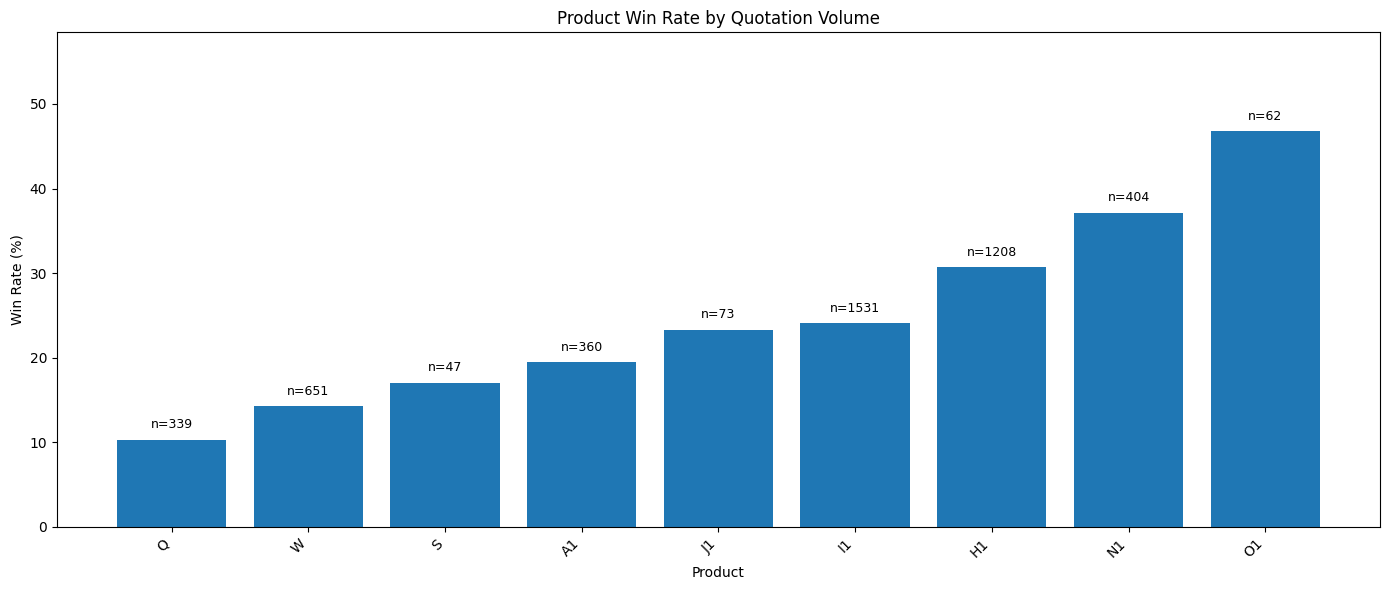

,product,total_quotes,success_count,fail_count,win_rate_pct
32,Q,339,35,304,10.324484
39,W,651,93,558,14.285714
35,S,47,8,39,17.021277
1,A1,360,70,290,19.444444
19,J1,73,17,56,23.287671
17,I1,1531,369,1162,24.101894
15,H1,1208,371,837,30.711921
27,N1,404,150,254,37.128713
29,O1,62,29,33,46.774194


In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
DATA = df.copy()   # ganti kalau nama dataframe kamu beda

PRODUCT_COL = "product"
TARGET_COL = "convert_to_order"   # 0 = Success, 1 = Fail

MIN_QUOTES = 30   # biar produk dengan data terlalu sedikit tidak misleading
TOP_N = 20        # tampilkan max 20 produk

# =========================
# PRODUCT WIN RATE SUMMARY
# =========================
product_summary = (
    DATA.groupby(PRODUCT_COL)
    .agg(
        total_quotes=(TARGET_COL, "count"),
        success_count=(TARGET_COL, lambda x: (x == 0).sum()),
        fail_count=(TARGET_COL, lambda x: (x == 1).sum())
    )
    .reset_index()
)

product_summary["win_rate_pct"] = (
    product_summary["success_count"] / product_summary["total_quotes"] * 100
)

# Filter produk dengan jumlah quotation cukup
plot_df = (
    product_summary[product_summary["total_quotes"] >= MIN_QUOTES]
    .sort_values("win_rate_pct", ascending=True)
    .head(TOP_N)
)

# =========================
# PLOT
# =========================
plt.figure(figsize=(14, 6))

bars = plt.bar(
    plot_df[PRODUCT_COL],
    plot_df["win_rate_pct"]
)

plt.title("Product Win Rate by Quotation Volume")
plt.xlabel("Product")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, max(plot_df["win_rate_pct"]) * 1.25)

# Add total quotation count above each bar
for bar, total in zip(bars, plot_df["total_quotes"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"n={total}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("../outputs/product_win_rate_by_volume.png", dpi=300, bbox_inches="tight")
plt.show()

# Optional: display table
plot_df

# Pricing Risk Score

## RULE BASE

Before cleaning: 4991
After cleaning : 4913
Dropped        : 78

Thresholds used:
Overall win rate: 0.2424
High GMR threshold, Q3: 0.4745
Very high GMR threshold, P90: 0.6191
Low GMR threshold, Q1: 0.2528
Very low GMR threshold, P10: 0.1182
Low grant ratio threshold, median: 0.3922
High price gap threshold, Q3: 36.4362

Review flag summary:


,quote_review_flag,total_quote_product_records,actual_win_rate,avg_conversion_risk_score,avg_profitability_risk_score,avg_gmr,avg_estimated_profit,actual_win_rate_pct,avg_gmr_pct
3,Review required: high conversion risk,1009,0.044599,78.025907,0.144143,0.561418,379839.904363,4.46,56.14
2,Review required: high conversion and profitabi...,1,0.000000,63.640000,90.910000,-1.322600,-211616.000000,0.00,-132.26
0,Monitor: medium pricing risk,2315,0.179266,34.892942,6.922536,0.322128,136532.757678,17.93,32.21
4,Review required: high profitability risk,57,0.736842,29.982281,91.388421,-0.056891,-25892.507603,73.68,-5.69
1,No major pricing risk,1531,0.450033,12.224357,8.074722,0.351343,204320.278675,45.00,35.13



Conversion risk vs profitability risk summary:


,conversion_risk_level,profitability_risk_level,total_records,actual_win_rate,avg_gmr,avg_estimated_profit,actual_win_rate_pct,avg_gmr_pct
0,High,High,1,0.000000,-1.322600,-211616.000000,0.00,-132.26
1,High,Low,1009,0.044599,0.561418,379839.904363,4.46,56.14
2,Low,High,27,1.000000,-0.083189,-36742.303087,100.00,-8.32
3,Low,Low,1531,0.450033,0.351343,204320.278675,45.00,35.13
4,Low,Medium,162,1.000000,0.079331,40414.195517,100.00,7.93
5,Medium,High,30,0.500000,-0.033223,-16127.691668,50.00,-3.32
6,Medium,Low,2153,0.117510,0.340397,143765.087948,11.75,34.04



Sample quote review output:


,quote_id,product,gross_margin_rate,unit_price,qty,subtotal_price,energy_grant_amount,grant_ratio_to_subtotal,competitor_count_available,avg_competitor_price,...,conversion_risk_level,profitability_risk_score,profitability_risk_level,quote_review_flag,conversion_review_reasons,profitability_review_reasons,review_explanation,success,gross_margin_rate_pct,grant_ratio_to_subtotal_pct
73,Q-05535,I1,0.6771,405000.0,2,810000.0,132000,0.162963,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 68.8% above average competitor; GMR i...,1,67.71,16.30
82,Q-05666,I1,0.6551,468000.0,1,468000.0,132000,0.282051,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 95.0% above average competitor; GMR i...,0,65.51,28.21
147,Q-06029,I1,0.6556,468000.0,1,468000.0,132000,0.282051,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 95.0% above average competitor; GMR i...,0,65.56,28.21
182,Q-06228,S,0.6407,3420000.0,1,3420000.0,528000,0.154386,1,1880000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 81.9% above average competitor; GMR i...,0,64.07,15.44
228,Q-06355,I1,0.6556,468000.0,1,468000.0,132000,0.282051,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 95.0% above average competitor; GMR i...,0,65.56,28.21
256,Q-06465,I1,0.6551,468000.0,1,468000.0,132000,0.282051,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 95.0% above average competitor; GMR i...,0,65.51,28.21
260,Q-06540,I1,0.6556,468000.0,1,468000.0,132000,0.282051,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 95.0% above average competitor; GMR i...,0,65.56,28.21
261,Q-06542,I1,0.6556,468000.0,1,468000.0,132000,0.282051,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 95.0% above average competitor; GMR i...,0,65.56,28.21
264,Q-06554,I1,0.6556,468000.0,1,468000.0,132000,0.282051,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 95.0% above average competitor; GMR i...,0,65.56,28.21
266,Q-06563,I1,0.6551,468000.0,2,936000.0,132000,0.141026,1,240000.0,...,High,0.0,Low,Review required: high conversion risk,High GMR; Very high GMR; Price higher than ave...,No major flag,price is 95.0% above average competitor; GMR i...,0,65.51,14.10


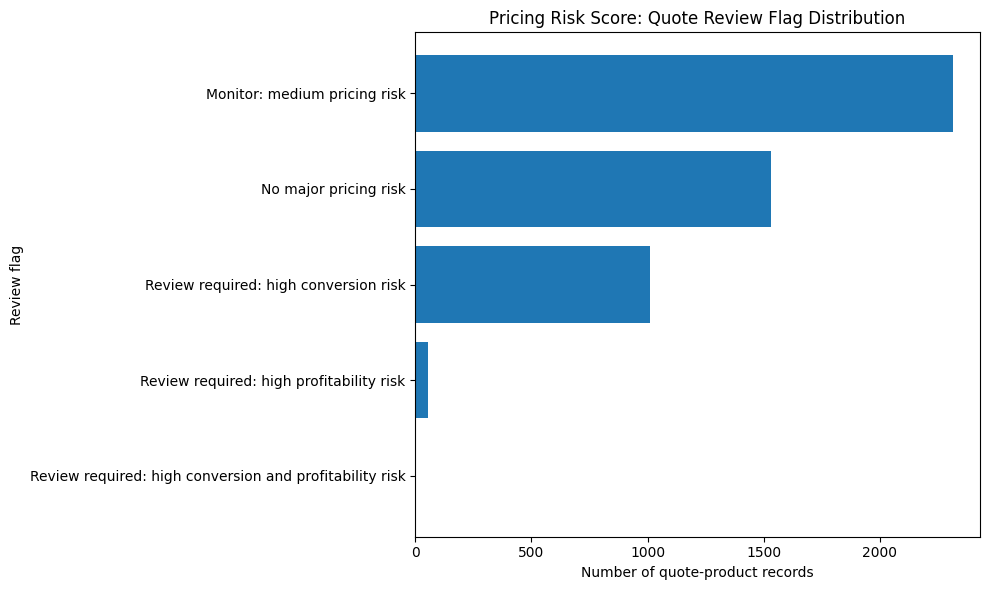


Saved files:
- pricing_risk_review_flag_summary.csv
- pricing_risk_level_summary.csv
- pricing_risk_quote_review_output.csv


In [109]:
# ============================================================
# PRICING RISK SCORE / QUOTE REVIEW FLAG
# Goal:
# Create a warning system to flag quotes that need review
# before submission.
#
# Risk types:
# 1. Conversion risk:
#    Likely to lose tender
#    Example: high GMR, price above competitors
#
# 2. Profitability risk:
#    Likely to win but hurt profit
#    Example: negative GMR, very low margin
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Prepare clean dataset
#    Rule: if same quote_id + product has different unit_price,
#    keep only the row with the highest unit price.
# ============================================================

df_risk = df.copy()

price_variation = (
    df_risk
    .groupby(["quote_id", "product"])["unit_price"]
    .transform("nunique")
)

df_risk = df_risk[
    (price_variation == 1) |
    ((price_variation > 1) & (df_risk["is_highest_price"] == 1))
].copy()

print("Before cleaning:", len(df))
print("After cleaning :", len(df_risk))
print("Dropped        :", len(df) - len(df_risk))


# ============================================================
# 2. Create target-related helper columns
#    Original:
#    convert_to_order = 0 means Success
#    convert_to_order = 1 means Fail
# ============================================================

df_risk["success"] = (df_risk["convert_to_order"] == 0).astype(int)
df_risk["failed"] = (df_risk["convert_to_order"] == 1).astype(int)


# ============================================================
# 3. Prepare required engineered features if not available
# ============================================================

# Estimated gross profit
if "estimated_gross_profit" not in df_risk.columns:
    df_risk["estimated_gross_profit"] = (
        df_risk["subtotal_price"] * df_risk["gross_margin_rate"]
    )

# Estimated cost
if "estimated_cost" not in df_risk.columns:
    df_risk["estimated_cost"] = (
        df_risk["subtotal_price"] - df_risk["estimated_gross_profit"]
    )

# Grant ratio
if "grant_ratio_to_subtotal" not in df_risk.columns:
    df_risk["grant_ratio_to_subtotal"] = (
        df_risk["energy_grant_amount"] / df_risk["subtotal_price"]
    )

# Competitor count
if "competitor_count_available" not in df_risk.columns:
    competitor_cols = [
        col for col in ["competitor_a", "competitor_b", "competitor_c"]
        if col in df_risk.columns
    ]
    df_risk["competitor_count_available"] = (
        df_risk[competitor_cols].notna().sum(axis=1)
    )

# Average competitor price
if "avg_competitor_price" not in df_risk.columns:
    competitor_cols = [
        col for col in ["competitor_a", "competitor_b", "competitor_c"]
        if col in df_risk.columns
    ]
    df_risk["avg_competitor_price"] = df_risk[competitor_cols].mean(axis=1)

# Price gap vs average competitor
if "price_gap_avg_competitor" not in df_risk.columns:
    df_risk["price_gap_avg_competitor"] = (
        df_risk["unit_price"] - df_risk["avg_competitor_price"]
    )

if "price_gap_avg_competitor_pct" not in df_risk.columns:
    df_risk["price_gap_avg_competitor_pct"] = (
        df_risk["price_gap_avg_competitor"] /
        df_risk["avg_competitor_price"]
    ) * 100

# Higher than average competitor
if "higher_than_avg_competitor" not in df_risk.columns:
    df_risk["higher_than_avg_competitor"] = (
        df_risk["price_gap_avg_competitor"] > 0
    ).astype(int)


# ============================================================
# 4. Define data-driven thresholds
#    These thresholds make the rules easier to defend.
# ============================================================

overall_win_rate = df_risk["success"].mean()

# High GMR: upper quartile of all data
high_gmr_threshold = df_risk["gross_margin_rate"].quantile(0.75)

# Very high GMR: upper decile
very_high_gmr_threshold = df_risk["gross_margin_rate"].quantile(0.90)

# Low GMR: 25th percentile, but keep negative margin rule separately
low_gmr_threshold = df_risk["gross_margin_rate"].quantile(0.25)

# Very low GMR: 10th percentile
very_low_gmr_threshold = df_risk["gross_margin_rate"].quantile(0.10)

# Low grant advantage: below median grant ratio
low_grant_threshold = df_risk["grant_ratio_to_subtotal"].median()

# High competitor price gap:
# price gap pct higher than 75th percentile among available competitor records
price_gap_available = df_risk["price_gap_avg_competitor_pct"].dropna()

if len(price_gap_available) > 0:
    high_price_gap_threshold = price_gap_available.quantile(0.75)
else:
    high_price_gap_threshold = np.nan

# Product historical win rate
product_win_rate = (
    df_risk
    .groupby("product")
    .agg(
        product_total_quotes=("quote_id", "count"),
        product_win_rate=("success", "mean")
    )
    .reset_index()
)

product_win_rate["low_win_rate_product"] = (
    product_win_rate["product_win_rate"] < overall_win_rate
).astype(int)

df_risk = df_risk.merge(
    product_win_rate,
    on="product",
    how="left"
)

print("\nThresholds used:")
print("Overall win rate:", round(overall_win_rate, 4))
print("High GMR threshold, Q3:", round(high_gmr_threshold, 4))
print("Very high GMR threshold, P90:", round(very_high_gmr_threshold, 4))
print("Low GMR threshold, Q1:", round(low_gmr_threshold, 4))
print("Very low GMR threshold, P10:", round(very_low_gmr_threshold, 4))
print("Low grant ratio threshold, median:", round(low_grant_threshold, 4))
print("High price gap threshold, Q3:", round(high_price_gap_threshold, 4))


# ============================================================
# 5. Create conversion risk flags
#    Higher score = higher risk of losing tender.
# ============================================================

# Conversion risk flag 1: High GMR
df_risk["conv_high_gmr"] = (
    df_risk["gross_margin_rate"] >= high_gmr_threshold
).astype(int)

# Conversion risk flag 2: Very high GMR
df_risk["conv_very_high_gmr"] = (
    df_risk["gross_margin_rate"] >= very_high_gmr_threshold
).astype(int)

# Conversion risk flag 3: Price higher than average competitor
df_risk["conv_price_higher_than_competitor"] = (
    df_risk["higher_than_avg_competitor"] == 1
).astype(int)

# Conversion risk flag 4: Price much higher than average competitor
# If price gap info is missing, set 0 because this flag cannot be verified.
df_risk["conv_price_much_higher_than_competitor"] = (
    (df_risk["price_gap_avg_competitor_pct"].notna()) &
    (df_risk["price_gap_avg_competitor_pct"] >= high_price_gap_threshold)
).astype(int)

# Conversion risk flag 5: Low or no grant advantage
df_risk["conv_low_or_no_grant"] = (
    (df_risk["energy_grant_amount"].fillna(0) <= 0) |
    (df_risk["grant_ratio_to_subtotal"].fillna(0) <= low_grant_threshold)
).astype(int)

# Conversion risk flag 6: Product historically low win rate
df_risk["conv_low_win_rate_product"] = (
    df_risk["low_win_rate_product"] == 1
).astype(int)

# Conversion risk flag 7: No competitor information
df_risk["conv_no_competitor_info"] = (
    df_risk["competitor_count_available"].fillna(0) == 0
).astype(int)


# ============================================================
# 6. Create profitability risk flags
#    Higher score = quote may win but hurt profitability.
# ============================================================

# Profitability risk flag 1: Negative GMR
df_risk["prof_negative_gmr"] = (
    df_risk["gross_margin_rate"] < 0
).astype(int)

# Profitability risk flag 2: Very low GMR
df_risk["prof_very_low_gmr"] = (
    df_risk["gross_margin_rate"] <= very_low_gmr_threshold
).astype(int)

# Profitability risk flag 3: Low GMR
df_risk["prof_low_gmr"] = (
    df_risk["gross_margin_rate"] <= low_gmr_threshold
).astype(int)

# Profitability risk flag 4: Negative estimated gross profit
df_risk["prof_negative_estimated_profit"] = (
    df_risk["estimated_gross_profit"] < 0
).astype(int)

# Profitability risk flag 5: Price lower than average competitor
# This may improve win chance but can hurt profit if margin is also low.
df_risk["prof_price_lower_than_competitor"] = (
    df_risk["price_gap_avg_competitor"] < 0
).astype(int)


# ============================================================
# 7. Calculate risk scores
#    Weighted rule-based score.
#    Score range is normalized to 0-100.
# ============================================================

conversion_weights = {
    "conv_high_gmr": 15,
    "conv_very_high_gmr": 15,
    "conv_price_higher_than_competitor": 25,
    "conv_price_much_higher_than_competitor": 20,
    "conv_low_or_no_grant": 15,
    "conv_low_win_rate_product": 10,
    "conv_no_competitor_info": 10
}

profitability_weights = {
    "prof_negative_gmr": 35,
    "prof_negative_estimated_profit": 35,
    "prof_very_low_gmr": 20,
    "prof_low_gmr": 10,
    "prof_price_lower_than_competitor": 10
}

df_risk["conversion_risk_raw"] = 0
for col, weight in conversion_weights.items():
    df_risk["conversion_risk_raw"] += df_risk[col] * weight

df_risk["profitability_risk_raw"] = 0
for col, weight in profitability_weights.items():
    df_risk["profitability_risk_raw"] += df_risk[col] * weight

df_risk["conversion_risk_score"] = (
    df_risk["conversion_risk_raw"] /
    sum(conversion_weights.values()) * 100
).round(2)

df_risk["profitability_risk_score"] = (
    df_risk["profitability_risk_raw"] /
    sum(profitability_weights.values()) * 100
).round(2)


# ============================================================
# 8. Create risk levels
# ============================================================

def risk_level(score):
    if score >= 60:
        return "High"
    elif score >= 30:
        return "Medium"
    else:
        return "Low"

df_risk["conversion_risk_level"] = df_risk["conversion_risk_score"].apply(risk_level)
df_risk["profitability_risk_level"] = df_risk["profitability_risk_score"].apply(risk_level)


# ============================================================
# 9. Create readable review reasons
# ============================================================

conversion_reason_map = {
    "conv_high_gmr": "High GMR",
    "conv_very_high_gmr": "Very high GMR",
    "conv_price_higher_than_competitor": "Price higher than average competitor",
    "conv_price_much_higher_than_competitor": "Price much higher than average competitor",
    "conv_low_or_no_grant": "Low or no energy grant advantage",
    "conv_low_win_rate_product": "Product has historically low win rate",
    "conv_no_competitor_info": "No competitor information available"
}

profitability_reason_map = {
    "prof_negative_gmr": "Negative GMR",
    "prof_negative_estimated_profit": "Negative estimated gross profit",
    "prof_very_low_gmr": "Very low GMR",
    "prof_low_gmr": "Low GMR",
    "prof_price_lower_than_competitor": "Price lower than average competitor"
}

def combine_flag_reasons(row, reason_map):
    reasons = []
    for col, label in reason_map.items():
        if row[col] == 1:
            reasons.append(label)
    if len(reasons) == 0:
        return "No major flag"
    return "; ".join(reasons)

df_risk["conversion_review_reasons"] = df_risk.apply(
    lambda row: combine_flag_reasons(row, conversion_reason_map),
    axis=1
)

df_risk["profitability_review_reasons"] = df_risk.apply(
    lambda row: combine_flag_reasons(row, profitability_reason_map),
    axis=1
)


# ============================================================
# 10. Overall quote review flag
# ============================================================

df_risk["needs_review"] = (
    (df_risk["conversion_risk_level"] == "High") |
    (df_risk["profitability_risk_level"] == "High")
).astype(int)

def final_review_flag(row):
    if row["conversion_risk_level"] == "High" and row["profitability_risk_level"] == "High":
        return "Review required: high conversion and profitability risk"
    elif row["conversion_risk_level"] == "High":
        return "Review required: high conversion risk"
    elif row["profitability_risk_level"] == "High":
        return "Review required: high profitability risk"
    elif row["conversion_risk_level"] == "Medium" or row["profitability_risk_level"] == "Medium":
        return "Monitor: medium pricing risk"
    else:
        return "No major pricing risk"

df_risk["quote_review_flag"] = df_risk.apply(final_review_flag, axis=1)


# ============================================================
# 11. Create example explanation sentence
# ============================================================

def create_review_explanation(row):
    explanation_parts = []

    # Conversion risk details
    if row["conv_price_higher_than_competitor"] == 1 and pd.notna(row["price_gap_avg_competitor_pct"]):
        explanation_parts.append(
            f"price is {row['price_gap_avg_competitor_pct']:.1f}% above average competitor"
        )

    if row["conv_high_gmr"] == 1:
        explanation_parts.append(
            f"GMR is {row['gross_margin_rate'] * 100:.1f}%"
        )

    if row["conv_low_or_no_grant"] == 1:
        explanation_parts.append(
            f"grant ratio is {row['grant_ratio_to_subtotal'] * 100:.1f}%"
        )

    if row["conv_low_win_rate_product"] == 1:
        explanation_parts.append(
            f"product historical win rate is {row['product_win_rate'] * 100:.1f}%"
        )

    if row["conv_no_competitor_info"] == 1:
        explanation_parts.append(
            "no competitor price information is available"
        )

    # Profitability risk details
    if row["prof_negative_gmr"] == 1:
        explanation_parts.append(
            "GMR is negative"
        )

    if row["prof_negative_estimated_profit"] == 1:
        explanation_parts.append(
            "estimated gross profit is negative"
        )

    if len(explanation_parts) == 0:
        return "No major pricing risk detected."

    return "; ".join(explanation_parts) + "."

df_risk["review_explanation"] = df_risk.apply(
    create_review_explanation,
    axis=1
)


# ============================================================
# 12. Summary tables
# ============================================================

review_flag_summary = (
    df_risk
    .groupby("quote_review_flag")
    .agg(
        total_quote_product_records=("quote_id", "count"),
        actual_win_rate=("success", "mean"),
        avg_conversion_risk_score=("conversion_risk_score", "mean"),
        avg_profitability_risk_score=("profitability_risk_score", "mean"),
        avg_gmr=("gross_margin_rate", "mean"),
        avg_estimated_profit=("estimated_gross_profit", "mean")
    )
    .reset_index()
)

review_flag_summary["actual_win_rate_pct"] = (
    review_flag_summary["actual_win_rate"] * 100
).round(2)

review_flag_summary["avg_gmr_pct"] = (
    review_flag_summary["avg_gmr"] * 100
).round(2)

review_flag_summary = review_flag_summary.sort_values(
    "avg_conversion_risk_score",
    ascending=False
)

print("\nReview flag summary:")
display(review_flag_summary)


risk_level_summary = (
    df_risk
    .groupby(["conversion_risk_level", "profitability_risk_level"])
    .agg(
        total_records=("quote_id", "count"),
        actual_win_rate=("success", "mean"),
        avg_gmr=("gross_margin_rate", "mean"),
        avg_estimated_profit=("estimated_gross_profit", "mean")
    )
    .reset_index()
)

risk_level_summary["actual_win_rate_pct"] = (
    risk_level_summary["actual_win_rate"] * 100
).round(2)

risk_level_summary["avg_gmr_pct"] = (
    risk_level_summary["avg_gmr"] * 100
).round(2)

print("\nConversion risk vs profitability risk summary:")
display(risk_level_summary)


# ============================================================
# 13. Output table for quote review
# ============================================================

quote_review_output_cols = [
    "quote_id",
    "product",
    "gross_margin_rate",
    "unit_price",
    "qty",
    "subtotal_price",
    "energy_grant_amount",
    "grant_ratio_to_subtotal",
    "competitor_count_available",
    "avg_competitor_price",
    "price_gap_avg_competitor_pct",
    "estimated_gross_profit",
    "conversion_risk_score",
    "conversion_risk_level",
    "profitability_risk_score",
    "profitability_risk_level",
    "quote_review_flag",
    "conversion_review_reasons",
    "profitability_review_reasons",
    "review_explanation",
    "success"
]

quote_review_output_cols = [
    col for col in quote_review_output_cols
    if col in df_risk.columns
]

quote_review_output = df_risk[quote_review_output_cols].copy()

quote_review_output["gross_margin_rate_pct"] = (
    quote_review_output["gross_margin_rate"] * 100
).round(2)

quote_review_output["grant_ratio_to_subtotal_pct"] = (
    quote_review_output["grant_ratio_to_subtotal"] * 100
).round(2)

if "price_gap_avg_competitor_pct" in quote_review_output.columns:
    quote_review_output["price_gap_avg_competitor_pct"] = (
        quote_review_output["price_gap_avg_competitor_pct"]
    ).round(2)

print("\nSample quote review output:")
display(
    quote_review_output.sort_values(
        ["conversion_risk_score", "profitability_risk_score"],
        ascending=False
    ).head(20)
)


# ============================================================
# 14. Visualization
# ============================================================

review_counts = (
    df_risk["quote_review_flag"]
    .value_counts()
    .reset_index()
)

review_counts.columns = ["quote_review_flag", "count"]

plt.figure(figsize=(10, 6))

plt.barh(
    review_counts["quote_review_flag"],
    review_counts["count"]
)

plt.gca().invert_yaxis()
plt.xlabel("Number of quote-product records")
plt.ylabel("Review flag")
plt.title("Pricing Risk Score: Quote Review Flag Distribution")
plt.tight_layout()
plt.show()


# ============================================================
# 15. Save outputs
# ============================================================

review_flag_summary.to_csv("../outputs/pricing_risk_review_flag_summary.csv", index=False)
risk_level_summary.to_csv("../outputs/pricing_risk_level_summary.csv", index=False)
quote_review_output.to_csv("../outputs/pricing_risk_quote_review_output.csv", index=False)

print("\nSaved files:")
print("- pricing_risk_review_flag_summary.csv")
print("- pricing_risk_level_summary.csv")
print("- pricing_risk_quote_review_output.csv")

## ISOLATION

Before cleaning: 4991
After cleaning : 4913
Dropped        : 78

Features used for Isolation Forest:
['product', 'kw', 'unit_price', 'qty', 'subtotal_price', 'gross_margin_rate', 'energy_grant_amount', 'competitor_a', 'competitor_b', 'competitor_c', 'is_compe_a', 'is_compe_b', 'is_compe_c', 'competitor_count_available', 'avg_competitor_price', 'min_competitor_price', 'max_competitor_price', 'price_order', 'price_gap_avg_competitor', 'price_gap_avg_competitor_pct', 'price_gap_min_competitor', 'price_gap_min_competitor_pct', 'higher_than_avg_competitor', 'is_lower_than_competitor', 'effective_price_after_grant', 'grant_ratio_to_subtotal', 'estimated_cost', 'estimated_gross_profit']

Categorical features:
['product']

Numeric features:
['kw', 'unit_price', 'qty', 'subtotal_price', 'gross_margin_rate', 'energy_grant_amount', 'competitor_a', 'competitor_b', 'competitor_c', 'is_compe_a', 'is_compe_b', 'is_compe_c', 'competitor_count_available', 'avg_competitor_price', 'min_competitor_price',

,anomaly_direction,total_records,anomaly_rate,actual_win_rate,avg_gmr,avg_anomaly_score,avg_estimated_profit,actual_win_rate_pct,avg_gmr_pct
0,Conversion risk review,53,1.0,0.245283,0.395908,77.95,1.135178e+06,24.53,39.59
1,High conversion risk review,68,1.0,0.044118,0.628822,74.11,1.653770e+06,4.41,62.88
4,Opportunity review,7,1.0,0.857143,0.544157,69.07,9.723214e+05,85.71,54.42
6,Unusual pricing pattern review,90,1.0,0.766667,0.258052,64.14,4.442517e+05,76.67,25.81
2,Information gap review,19,1.0,0.421053,0.399537,61.79,1.817428e+06,42.11,39.95
5,Profitability risk review,9,1.0,0.888889,-0.209489,60.52,-1.128213e+05,88.89,-20.95
3,Normal pricing pattern,4667,0.0,0.232269,0.374771,15.40,1.623170e+05,23.23,37.48



Top anomalous quotes for review:


,quote_id,product,kw,unit_price,qty,subtotal_price,gross_margin_rate,energy_grant_amount,grant_ratio_to_subtotal,competitor_count_available,avg_competitor_price,price_gap_avg_competitor_pct,estimated_gross_profit,is_anomaly,pricing_anomaly_score_0_100,anomaly_direction,anomaly_explanation,success,gross_margin_rate_pct,grant_ratio_to_subtotal_pct
987,Q-11707,E1,200.0,4600000.00,1,4600000.00,0.0973,960000,0.208696,1,2000000.0,130.00,4.475800e+05,1,100.00,Conversion risk review,price is 130.0% above average competitor; low ...,1,9.73,20.87
989,Q-11708,E1,200.0,4600000.00,1,4600000.00,0.0933,960000,0.208696,1,2000000.0,130.00,4.291800e+05,1,99.87,Conversion risk review,price is 130.0% above average competitor; low ...,1,9.33,20.87
1092,Q-12530,D1,200.0,4600000.00,1,4600000.00,0.6179,960000,0.208696,1,2000000.0,130.00,2.842340e+06,1,99.46,High conversion risk review,high GMR (61.8%); price is 130.0% above averag...,0,61.79,20.87
1093,Q-12532,D1,200.0,4600000.00,1,4600000.00,0.6181,960000,0.208696,1,2000000.0,130.00,2.843260e+06,1,99.46,High conversion risk review,high GMR (61.8%); price is 130.0% above averag...,0,61.81,20.87
2177,Q-18581,D1,200.0,4600000.00,1,4600000.00,0.6181,960000,0.208696,1,2000000.0,130.00,2.843260e+06,1,99.46,High conversion risk review,high GMR (61.8%); price is 130.0% above averag...,0,61.81,20.87
2111,Q-18203,D1,200.0,4600000.00,1,4600000.00,0.6181,960000,0.208696,1,2000000.0,130.00,2.843260e+06,1,99.46,High conversion risk review,high GMR (61.8%); price is 130.0% above averag...,0,61.81,20.87
3457,Q-28185,D1,200.0,4600000.00,1,4600000.00,0.6181,960000,0.208696,1,2000000.0,130.00,2.843260e+06,1,99.46,High conversion risk review,high GMR (61.8%); price is 130.0% above averag...,0,61.81,20.87
3688,Q-30348,D1,200.0,4600000.00,1,4600000.00,0.6181,960000,0.208696,1,2000000.0,130.00,2.843260e+06,1,99.46,High conversion risk review,high GMR (61.8%); price is 130.0% above averag...,0,61.81,20.87
4249,Q-37235,F1,200.0,4600000.00,1,4600000.00,0.6414,960000,0.208696,1,2000000.0,130.00,2.950440e+06,1,97.51,High conversion risk review,very high GMR (64.1%); price is 130.0% above a...,0,64.14,20.87
4202,Q-36776,F1,200.0,4600000.00,1,4600000.00,0.6413,960000,0.208696,1,2000000.0,130.00,2.949980e+06,1,97.51,High conversion risk review,very high GMR (64.1%); price is 130.0% above a...,0,64.13,20.87


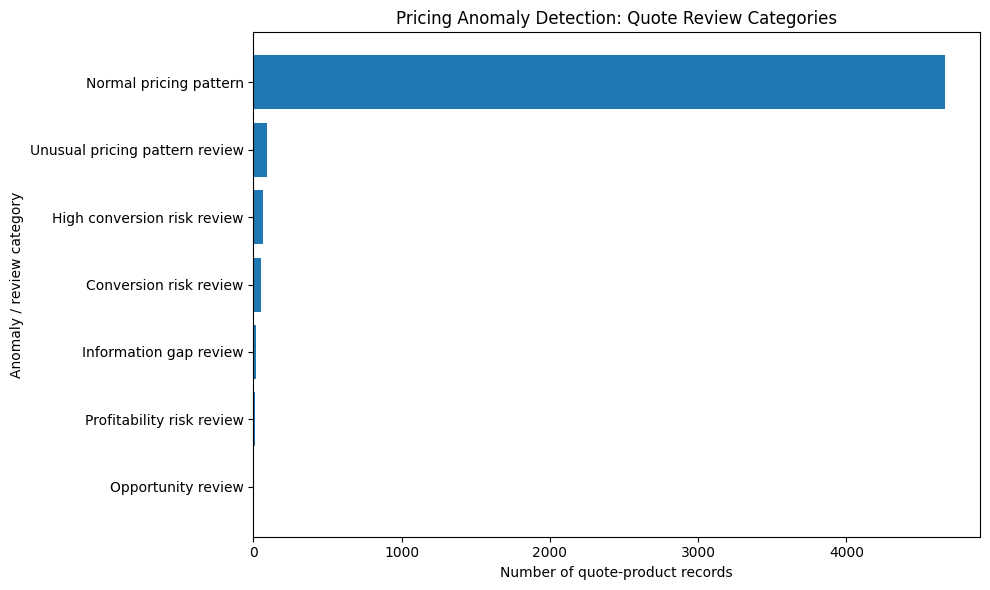

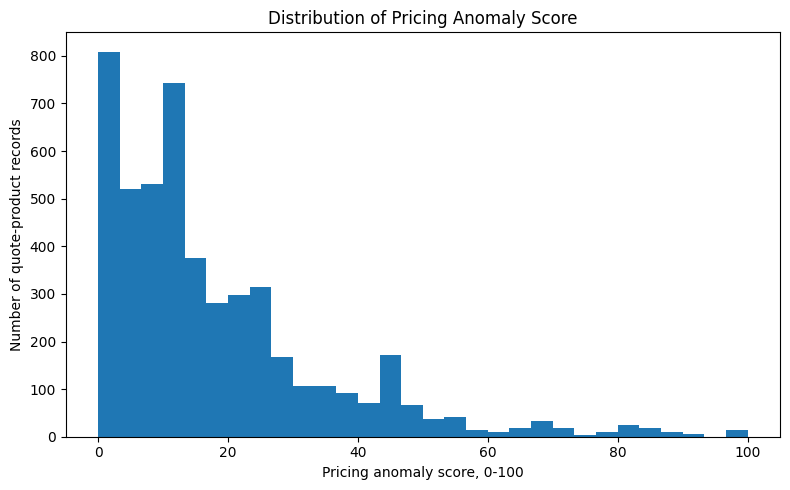


Saved files:
- pricing_anomaly_summary.csv
- pricing_anomaly_quote_review_output.csv


In [110]:
# ============================================================
# PRICING ANOMALY DETECTION / QUOTE REVIEW FLAG
# Method: Isolation Forest
#
# Goal:
# Detect unusual pricing patterns that may need manual review
# before quote submission.
#
# Important:
# - This is NOT a win/loss prediction model.
# - This is NOT a direct risk probability model.
# - Isolation Forest detects unusual records compared to
#   historical quote patterns.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# ============================================================
# 1. Prepare clean dataset
#    Rule from data owner:
#    if same quote_id + product has different unit_price,
#    keep only the row with the highest unit price.
# ============================================================

df_iso = df.copy()

price_variation = (
    df_iso
    .groupby(["quote_id", "product"])["unit_price"]
    .transform("nunique")
)

df_iso = df_iso[
    (price_variation == 1) |
    ((price_variation > 1) & (df_iso["is_highest_price"] == 1))
].copy()

print("Before cleaning:", len(df))
print("After cleaning :", len(df_iso))
print("Dropped        :", len(df) - len(df_iso))


# ============================================================
# 2. Create helper columns
# ============================================================

# Original:
# convert_to_order = 0 means Success
# convert_to_order = 1 means Fail
df_iso["success"] = (df_iso["convert_to_order"] == 0).astype(int)
df_iso["failed"] = (df_iso["convert_to_order"] == 1).astype(int)

# Estimated gross profit
if "estimated_gross_profit" not in df_iso.columns:
    df_iso["estimated_gross_profit"] = (
        df_iso["subtotal_price"] * df_iso["gross_margin_rate"]
    )

# Estimated cost
if "estimated_cost" not in df_iso.columns:
    df_iso["estimated_cost"] = (
        df_iso["subtotal_price"] - df_iso["estimated_gross_profit"]
    )

# Effective price after grant
if "effective_price_after_grant" not in df_iso.columns:
    df_iso["effective_price_after_grant"] = (
        df_iso["subtotal_price"] - df_iso["energy_grant_amount"].fillna(0)
    )

# Grant ratio
if "grant_ratio_to_subtotal" not in df_iso.columns:
    df_iso["grant_ratio_to_subtotal"] = (
        df_iso["energy_grant_amount"] / df_iso["subtotal_price"]
    )

# Competitor count
if "competitor_count_available" not in df_iso.columns:
    competitor_cols_raw = [
        col for col in ["competitor_a", "competitor_b", "competitor_c"]
        if col in df_iso.columns
    ]
    df_iso["competitor_count_available"] = (
        df_iso[competitor_cols_raw].notna().sum(axis=1)
    )

# Average competitor price
if "avg_competitor_price" not in df_iso.columns:
    competitor_cols_raw = [
        col for col in ["competitor_a", "competitor_b", "competitor_c"]
        if col in df_iso.columns
    ]
    df_iso["avg_competitor_price"] = df_iso[competitor_cols_raw].mean(axis=1)

# Min competitor price
if "min_competitor_price" not in df_iso.columns:
    competitor_cols_raw = [
        col for col in ["competitor_a", "competitor_b", "competitor_c"]
        if col in df_iso.columns
    ]
    df_iso["min_competitor_price"] = df_iso[competitor_cols_raw].min(axis=1)

# Max competitor price
if "max_competitor_price" not in df_iso.columns:
    competitor_cols_raw = [
        col for col in ["competitor_a", "competitor_b", "competitor_c"]
        if col in df_iso.columns
    ]
    df_iso["max_competitor_price"] = df_iso[competitor_cols_raw].max(axis=1)

# Price gap vs average competitor
if "price_gap_avg_competitor" not in df_iso.columns:
    df_iso["price_gap_avg_competitor"] = (
        df_iso["unit_price"] - df_iso["avg_competitor_price"]
    )

if "price_gap_avg_competitor_pct" not in df_iso.columns:
    df_iso["price_gap_avg_competitor_pct"] = (
        df_iso["price_gap_avg_competitor"] /
        df_iso["avg_competitor_price"]
    ) * 100

# Price gap vs min competitor
if "price_gap_min_competitor" not in df_iso.columns:
    df_iso["price_gap_min_competitor"] = (
        df_iso["unit_price"] - df_iso["min_competitor_price"]
    )

if "price_gap_min_competitor_pct" not in df_iso.columns:
    df_iso["price_gap_min_competitor_pct"] = (
        df_iso["price_gap_min_competitor"] /
        df_iso["min_competitor_price"]
    ) * 100

# Higher / lower than competitor flags
if "higher_than_avg_competitor" not in df_iso.columns:
    df_iso["higher_than_avg_competitor"] = (
        df_iso["price_gap_avg_competitor"] > 0
    ).astype(int)

if "is_lower_than_competitor" not in df_iso.columns:
    df_iso["is_lower_than_competitor"] = (
        df_iso["price_gap_min_competitor"] < 0
    ).astype(int)


# ============================================================
# 3. Select features for anomaly detection
#
# Important:
# - Do NOT use convert_to_order, success, or failed as features.
# - Do NOT use is_highest_price as feature because it is only
#   a cleaning helper.
# - Missing competitor price will be imputed technically, but
#   missingness is still represented by competitor_count_available
#   and other availability flags.
# ============================================================

candidate_features = [
    # categorical
    "product",

    # basic quote / pricing
    "kw",
    "unit_price",
    "qty",
    "subtotal_price",
    "gross_margin_rate",
    "energy_grant_amount",

    # competitor raw prices
    "competitor_a",
    "competitor_b",
    "competitor_c",

    # competitor availability
    "is_compe_a",
    "is_compe_b",
    "is_compe_c",
    "competitor_count_available",

    # competitor summary
    "avg_competitor_price",
    "min_competitor_price",
    "max_competitor_price",

    # competitor positioning
    "price_order",
    "price_gap_avg_competitor",
    "price_gap_avg_competitor_pct",
    "price_gap_min_competitor",
    "price_gap_min_competitor_pct",
    "higher_than_avg_competitor",
    "is_lower_than_competitor",

    # grant and profit
    "effective_price_after_grant",
    "grant_ratio_to_subtotal",
    "estimated_cost",
    "estimated_gross_profit"
]

# Keep only columns that exist in df_iso
features_iso = [col for col in candidate_features if col in df_iso.columns]

categorical_features_iso = [
    col for col in ["product"]
    if col in features_iso
]

numeric_features_iso = [
    col for col in features_iso
    if col not in categorical_features_iso
]

print("\nFeatures used for Isolation Forest:")
print(features_iso)

print("\nCategorical features:")
print(categorical_features_iso)

print("\nNumeric features:")
print(numeric_features_iso)


# ============================================================
# 4. Preprocessing
#
# IsolationForest needs numeric input and cannot directly handle
# raw strings/categorical columns.
# ColumnTransformer lets us process numeric and categorical
# features differently. This is recommended for mixed-type data.
# ============================================================

numeric_transformer_iso = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_iso = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_iso = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_iso, numeric_features_iso),
        ("cat", categorical_transformer_iso, categorical_features_iso)
    ]
)


# ============================================================
# 5. Fit Isolation Forest
#
# contamination:
# Expected proportion of anomaly.
# Example:
# contamination = 0.05 means around 5% records will be flagged
# as anomalous.
#
# You can try 0.03, 0.05, or 0.10 depending on how strict you want
# the review system to be.
# ============================================================

X_iso = df_iso[features_iso].copy()

contamination_rate = 0.05

iso_model = Pipeline(steps=[
    ("preprocess", preprocess_iso),
    ("model", IsolationForest(
        n_estimators=300,
        contamination=contamination_rate,
        random_state=42,
        n_jobs=-1
    ))
])

iso_model.fit(X_iso)


# ============================================================
# 6. Create anomaly score and anomaly flag
#
# predict output:
#  1  = normal / inlier
# -1  = anomalous / outlier
#
# decision_function:
# higher = more normal
# lower  = more anomalous
#
# To make it easier to read:
# anomaly_score = -decision_function
# higher anomaly_score = more anomalous
# ============================================================

df_iso["isolation_prediction"] = iso_model.predict(X_iso)

df_iso["is_anomaly"] = (
    df_iso["isolation_prediction"] == -1
).astype(int)

df_iso["isolation_decision_score"] = iso_model.decision_function(X_iso)

df_iso["pricing_anomaly_score"] = (
    -df_iso["isolation_decision_score"]
)

# Normalize anomaly score to 0-100 for easier review
min_score = df_iso["pricing_anomaly_score"].min()
max_score = df_iso["pricing_anomaly_score"].max()

df_iso["pricing_anomaly_score_0_100"] = (
    (df_iso["pricing_anomaly_score"] - min_score) /
    (max_score - min_score) * 100
).round(2)


# ============================================================
# 7. Add interpretation / direction layer
#
# Isolation Forest only detects unusualness.
# This section translates anomaly into business review category.
# ============================================================

# Data-driven thresholds for interpretation
high_gmr_threshold = df_iso["gross_margin_rate"].quantile(0.75)
very_high_gmr_threshold = df_iso["gross_margin_rate"].quantile(0.90)
low_gmr_threshold = df_iso["gross_margin_rate"].quantile(0.25)
very_low_gmr_threshold = df_iso["gross_margin_rate"].quantile(0.10)

low_grant_threshold = df_iso["grant_ratio_to_subtotal"].median()

price_gap_available = df_iso["price_gap_avg_competitor_pct"].dropna()
if len(price_gap_available) > 0:
    high_price_gap_threshold = price_gap_available.quantile(0.75)
else:
    high_price_gap_threshold = np.nan

print("\nInterpretation thresholds:")
print("High GMR threshold, Q3:", round(high_gmr_threshold, 4))
print("Very high GMR threshold, P90:", round(very_high_gmr_threshold, 4))
print("Low GMR threshold, Q1:", round(low_gmr_threshold, 4))
print("Very low GMR threshold, P10:", round(very_low_gmr_threshold, 4))
print("Low grant ratio threshold, median:", round(low_grant_threshold, 4))
print("High price gap threshold, Q3:", round(high_price_gap_threshold, 4))


# Business reason flags
df_iso["flag_high_gmr"] = (
    df_iso["gross_margin_rate"] >= high_gmr_threshold
).astype(int)

df_iso["flag_very_high_gmr"] = (
    df_iso["gross_margin_rate"] >= very_high_gmr_threshold
).astype(int)

df_iso["flag_negative_gmr"] = (
    df_iso["gross_margin_rate"] < 0
).astype(int)

df_iso["flag_low_gmr"] = (
    df_iso["gross_margin_rate"] <= low_gmr_threshold
).astype(int)

df_iso["flag_negative_profit"] = (
    df_iso["estimated_gross_profit"] < 0
).astype(int)

df_iso["flag_price_above_competitor"] = (
    df_iso["price_gap_avg_competitor_pct"] > 0
).astype(int)

df_iso["flag_price_much_above_competitor"] = (
    (df_iso["price_gap_avg_competitor_pct"].notna()) &
    (df_iso["price_gap_avg_competitor_pct"] >= high_price_gap_threshold)
).astype(int)

df_iso["flag_low_or_no_grant"] = (
    (df_iso["energy_grant_amount"].fillna(0) <= 0) |
    (df_iso["grant_ratio_to_subtotal"].fillna(0) <= low_grant_threshold)
).astype(int)

df_iso["flag_no_competitor_info"] = (
    df_iso["competitor_count_available"].fillna(0) == 0
).astype(int)

df_iso["flag_price_below_competitor"] = (
    df_iso["price_gap_avg_competitor_pct"] < 0
).astype(int)


# ============================================================
# 8. Classify anomaly direction
# ============================================================

def classify_anomaly_direction(row):
    # Not anomalous
    if row["is_anomaly"] == 0:
        return "Normal pricing pattern"

    # Profitability risk comes first
    if row["flag_negative_gmr"] == 1 or row["flag_negative_profit"] == 1:
        return "Profitability risk review"

    # Conversion risk
    if (
        row["flag_very_high_gmr"] == 1
        and row["flag_price_above_competitor"] == 1
    ):
        return "High conversion risk review"

    if (
        row["flag_high_gmr"] == 1
        and row["flag_price_much_above_competitor"] == 1
    ):
        return "High conversion risk review"

    if (
        row["flag_price_above_competitor"] == 1
        and row["flag_low_or_no_grant"] == 1
    ):
        return "Conversion risk review"

    # Opportunity anomaly
    if (
        row["flag_high_gmr"] == 1
        and row["flag_price_below_competitor"] == 1
        and row["flag_negative_profit"] == 0
    ):
        return "Opportunity review"

    # Data / information issue
    if row["flag_no_competitor_info"] == 1:
        return "Information gap review"

    # Catch-all
    return "Unusual pricing pattern review"

df_iso["anomaly_direction"] = df_iso.apply(
    classify_anomaly_direction,
    axis=1
)


# ============================================================
# 9. Create readable explanation
# ============================================================

def create_anomaly_explanation(row):
    if row["is_anomaly"] == 0:
        return "No anomaly detected."

    reasons = []

    if row["flag_negative_gmr"] == 1:
        reasons.append("negative GMR")

    if row["flag_negative_profit"] == 1:
        reasons.append("negative estimated gross profit")

    if row["flag_very_high_gmr"] == 1:
        reasons.append(
            f"very high GMR ({row['gross_margin_rate'] * 100:.1f}%)"
        )
    elif row["flag_high_gmr"] == 1:
        reasons.append(
            f"high GMR ({row['gross_margin_rate'] * 100:.1f}%)"
        )

    if (
        row["flag_price_much_above_competitor"] == 1
        and pd.notna(row["price_gap_avg_competitor_pct"])
    ):
        reasons.append(
            f"price is {row['price_gap_avg_competitor_pct']:.1f}% above average competitor"
        )
    elif (
        row["flag_price_above_competitor"] == 1
        and pd.notna(row["price_gap_avg_competitor_pct"])
    ):
        reasons.append(
            f"price is {row['price_gap_avg_competitor_pct']:.1f}% above average competitor"
        )

    if (
        row["flag_price_below_competitor"] == 1
        and pd.notna(row["price_gap_avg_competitor_pct"])
    ):
        reasons.append(
            f"price is {abs(row['price_gap_avg_competitor_pct']):.1f}% below average competitor"
        )

    if row["flag_low_or_no_grant"] == 1:
        if pd.notna(row["grant_ratio_to_subtotal"]):
            reasons.append(
                f"low grant ratio ({row['grant_ratio_to_subtotal'] * 100:.1f}%)"
            )
        else:
            reasons.append("low or missing grant advantage")

    if row["flag_no_competitor_info"] == 1:
        reasons.append("no competitor price information")

    if len(reasons) == 0:
        return "Anomalous pattern detected, but no simple business rule explains it."

    return "; ".join(reasons) + "."

df_iso["anomaly_explanation"] = df_iso.apply(
    create_anomaly_explanation,
    axis=1
)


# ============================================================
# 10. Summary output
# ============================================================

anomaly_summary = (
    df_iso
    .groupby("anomaly_direction")
    .agg(
        total_records=("quote_id", "count"),
        anomaly_rate=("is_anomaly", "mean"),
        actual_win_rate=("success", "mean"),
        avg_gmr=("gross_margin_rate", "mean"),
        avg_anomaly_score=("pricing_anomaly_score_0_100", "mean"),
        avg_estimated_profit=("estimated_gross_profit", "mean")
    )
    .reset_index()
)

anomaly_summary["actual_win_rate_pct"] = (
    anomaly_summary["actual_win_rate"] * 100
).round(2)

anomaly_summary["avg_gmr_pct"] = (
    anomaly_summary["avg_gmr"] * 100
).round(2)

anomaly_summary["avg_anomaly_score"] = (
    anomaly_summary["avg_anomaly_score"]
).round(2)

anomaly_summary = anomaly_summary.sort_values(
    "avg_anomaly_score",
    ascending=False
)

print("\nAnomaly direction summary:")
display(anomaly_summary)


# ============================================================
# 11. Quote-level review output
# ============================================================

quote_anomaly_output_cols = [
    "quote_id",
    "product",
    "kw",
    "unit_price",
    "qty",
    "subtotal_price",
    "gross_margin_rate",
    "energy_grant_amount",
    "grant_ratio_to_subtotal",
    "competitor_count_available",
    "avg_competitor_price",
    "price_gap_avg_competitor_pct",
    "estimated_gross_profit",
    "is_anomaly",
    "pricing_anomaly_score_0_100",
    "anomaly_direction",
    "anomaly_explanation",
    "success"
]

quote_anomaly_output_cols = [
    col for col in quote_anomaly_output_cols
    if col in df_iso.columns
]

quote_anomaly_output = df_iso[quote_anomaly_output_cols].copy()

quote_anomaly_output["gross_margin_rate_pct"] = (
    quote_anomaly_output["gross_margin_rate"] * 100
).round(2)

quote_anomaly_output["grant_ratio_to_subtotal_pct"] = (
    quote_anomaly_output["grant_ratio_to_subtotal"] * 100
).round(2)

if "price_gap_avg_competitor_pct" in quote_anomaly_output.columns:
    quote_anomaly_output["price_gap_avg_competitor_pct"] = (
        quote_anomaly_output["price_gap_avg_competitor_pct"]
    ).round(2)

print("\nTop anomalous quotes for review:")
display(
    quote_anomaly_output
    .sort_values("pricing_anomaly_score_0_100", ascending=False)
    .head(30)
)


# ============================================================
# 12. Visualization
# ============================================================

anomaly_counts = (
    df_iso["anomaly_direction"]
    .value_counts()
    .reset_index()
)

anomaly_counts.columns = ["anomaly_direction", "count"]

plt.figure(figsize=(10, 6))

plt.barh(
    anomaly_counts["anomaly_direction"],
    anomaly_counts["count"]
)

plt.gca().invert_yaxis()
plt.xlabel("Number of quote-product records")
plt.ylabel("Anomaly / review category")
plt.title("Pricing Anomaly Detection: Quote Review Categories")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.hist(
    df_iso["pricing_anomaly_score_0_100"],
    bins=30
)

plt.xlabel("Pricing anomaly score, 0-100")
plt.ylabel("Number of quote-product records")
plt.title("Distribution of Pricing Anomaly Score")
plt.tight_layout()
plt.show()


# ============================================================
# 13. Save outputs
# ============================================================

anomaly_summary.to_csv("../outputs/pricing_anomaly_summary.csv", index=False)
quote_anomaly_output.to_csv("../outputs/pricing_anomaly_quote_review_output.csv", index=False)

print("\nSaved files:")
print("- pricing_anomaly_summary.csv")
print("- pricing_anomaly_quote_review_output.csv")

## DIFFI

Transformed X shape: (4913, 70)
Number of transformed features: 70
Number of anomalous records explained by Local-DIFFI: 100

Local-DIFFI long format:


,original_feature,local_diffi_importance,max_transformed_importance,row_index,quote_id,product,pricing_anomaly_score_0_100,anomaly_direction
0,product,1.730355,0.295476,987,Q-11707,E1,100.00,Conversion risk review
1,is_compe_c,0.141558,0.141558,987,Q-11707,E1,100.00,Conversion risk review
2,estimated_cost,0.137196,0.137196,987,Q-11707,E1,100.00,Conversion risk review
3,price_gap_min_competitor,0.123909,0.123909,987,Q-11707,E1,100.00,Conversion risk review
4,subtotal_price,0.110604,0.110604,987,Q-11707,E1,100.00,Conversion risk review
5,avg_competitor_price,0.103260,0.103260,987,Q-11707,E1,100.00,Conversion risk review
6,price_gap_avg_competitor,0.099107,0.099107,987,Q-11707,E1,100.00,Conversion risk review
7,unit_price,0.096746,0.096746,987,Q-11707,E1,100.00,Conversion risk review
8,is_compe_a,0.094240,0.094240,987,Q-11707,E1,100.00,Conversion risk review
9,energy_grant_amount,0.083011,0.083011,987,Q-11707,E1,100.00,Conversion risk review



Local-DIFFI summary per quote:


C:\Users\surya\AppData\Local\Temp\ipykernel_19076\1936553114.py:271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: top_diffi_features_for_quote(g, top_k=5))


,row_index,quote_id,product,pricing_anomaly_score_0_100,anomaly_direction,top_local_diffi_features
0,29,Q-02428,S,72.96,Unusual pricing pattern review,product (0.9576); price_gap_avg_competitor (0....
1,31,Q-02733,S,88.34,Unusual pricing pattern review,product (1.3669); estimated_cost (0.0933); sub...
2,191,Q-06228,S,88.14,High conversion risk review,product (1.1650); unit_price (0.0804); price_g...
3,225,Q-06327,T,83.84,High conversion risk review,product (1.3727); price_gap_min_competitor (0....
4,298,Q-06634,S,80.75,Conversion risk review,product (0.9219); subtotal_price (0.0659); eff...
5,299,Q-06635,S,80.75,Conversion risk review,product (0.9219); subtotal_price (0.0659); eff...
6,310,Q-06683,S,88.10,High conversion risk review,product (1.1567); unit_price (0.0795); price_g...
7,469,Q-07853,D1,93.21,Conversion risk review,product (1.3530); is_compe_c (0.1157); avg_com...
8,513,Q-08241,T,80.34,Unusual pricing pattern review,product (1.2728); subtotal_price (0.0673); avg...
9,529,Q-08465,T,84.04,High conversion risk review,product (1.4202); estimated_gross_profit (0.08...


...

,row_index,quote_id,product,pricing_anomaly_score_0_100,anomaly_direction,top_local_diffi_features,local_diffi_business_explanation
0,29,Q-02428,S,72.96,Unusual pricing pattern review,product (0.9576); price_gap_avg_competitor (0....,product category contributes to unusual pricin...
1,31,Q-02733,S,88.34,Unusual pricing pattern review,product (1.3669); estimated_cost (0.0933); sub...,product category contributes to unusual pricin...
2,191,Q-06228,S,88.14,High conversion risk review,product (1.1650); unit_price (0.0804); price_g...,product category contributes to unusual pricin...
3,225,Q-06327,T,83.84,High conversion risk review,product (1.3727); price_gap_min_competitor (0....,product category contributes to unusual pricin...
4,298,Q-06634,S,80.75,Conversion risk review,product (0.9219); subtotal_price (0.0659); eff...,product category contributes to unusual pricin...
5,299,Q-06635,S,80.75,Conversion risk review,product (0.9219); subtotal_price (0.0659); eff...,product category contributes to unusual pricin...
6,310,Q-06683,S,88.10,High conversion risk review,product (1.1567); unit_price (0.0795); price_g...,product category contributes to unusual pricin...
7,469,Q-07853,D1,93.21,Conversion risk review,product (1.3530); is_compe_c (0.1157); avg_com...,product category contributes to unusual pricin...
8,513,Q-08241,T,80.34,Unusual pricing pattern review,product (1.2728); subtotal_price (0.0673); avg...,product category contributes to unusual pricin...
9,529,Q-08465,T,84.04,High conversion risk review,product (1.4202); estimated_gross_profit (0.08...,product category contributes to unusual pricin...



Final quote-level Local-DIFFI output:


,quote_id,product,gross_margin_rate,unit_price,qty,subtotal_price,energy_grant_amount,grant_ratio_to_subtotal,competitor_count_available,avg_competitor_price,price_gap_avg_competitor_pct,estimated_gross_profit,pricing_anomaly_score_0_100,anomaly_direction,top_local_diffi_features,local_diffi_business_explanation,success,gross_margin_rate_pct,grant_ratio_to_subtotal_pct
20,Q-11707,E1,0.0973,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,4.475800e+05,100.00,Conversion risk review,product (1.7304); is_compe_c (0.1416); estimat...,product category contributes to unusual pricin...,1,9.73,20.87
21,Q-11708,E1,0.0933,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,4.291800e+05,99.87,Conversion risk review,product (1.7280); is_compe_c (0.1416); estimat...,product category contributes to unusual pricin...,1,9.33,20.87
27,Q-12530,D1,0.6179,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,2.842340e+06,99.46,High conversion risk review,product (1.5866); is_compe_c (0.1420); price_g...,product category contributes to unusual pricin...,0,61.79,20.87
28,Q-12532,D1,0.6181,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,2.843260e+06,99.46,High conversion risk review,product (1.5866); is_compe_c (0.1420); price_g...,product category contributes to unusual pricin...,0,61.81,20.87
32,Q-18203,D1,0.6181,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,2.843260e+06,99.46,High conversion risk review,product (1.5866); is_compe_c (0.1420); price_g...,product category contributes to unusual pricin...,0,61.81,20.87
36,Q-18581,D1,0.6181,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,2.843260e+06,99.46,High conversion risk review,product (1.5866); is_compe_c (0.1420); price_g...,product category contributes to unusual pricin...,0,61.81,20.87
66,Q-30348,D1,0.6181,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,2.843260e+06,99.46,High conversion risk review,product (1.5866); is_compe_c (0.1420); price_g...,product category contributes to unusual pricin...,0,61.81,20.87
61,Q-28185,D1,0.6181,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,2.843260e+06,99.46,High conversion risk review,product (1.5866); is_compe_c (0.1420); price_g...,product category contributes to unusual pricin...,0,61.81,20.87
79,Q-37235,F1,0.6414,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,2.950440e+06,97.51,High conversion risk review,product (1.6351); is_compe_c (0.1473); price_g...,product category contributes to unusual pricin...,0,64.14,20.87
48,Q-21423,F1,0.6414,4600000.00,1,4600000.00,960000,0.208696,1,2000000.0,130.00,2.950440e+06,97.51,High conversion risk review,product (1.6351); is_compe_c (0.1473); price_g...,product category contributes to unusual pricin...,0,64.14,20.87



Feature summary from Local-DIFFI explanations:


,original_feature,avg_local_diffi_importance,max_local_diffi_importance,total_local_diffi_importance,appeared_in_top_anomalies
21,product,1.175371,1.730355,117.537091,97
0,avg_competitor_price,0.077415,0.112366,7.741479,97
11,is_compe_c,0.112690,0.147288,6.761375,58
18,price_gap_min_competitor,0.077090,0.135714,5.627563,72
24,unit_price,0.072989,0.106577,5.547189,75
16,price_gap_avg_competitor,0.063312,0.099123,5.254894,82
9,is_compe_a,0.067787,0.106106,4.948467,72
14,max_competitor_price,0.058903,0.089415,4.123235,67
23,subtotal_price,0.080607,0.110604,3.788542,46
15,min_competitor_price,0.053285,0.069994,3.090537,57


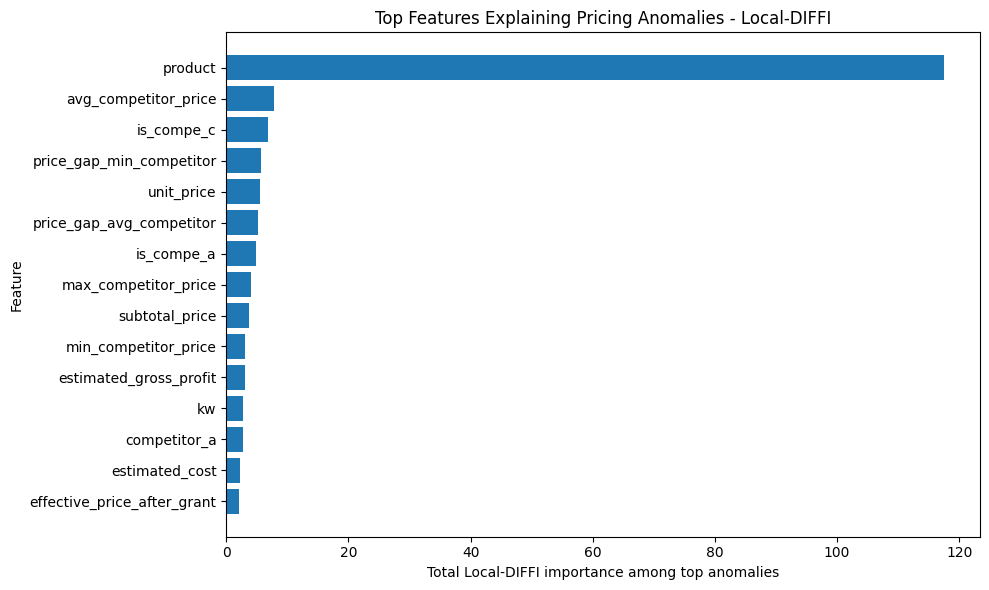


Saved files:
- local_diffi_long.csv
- local_diffi_summary.csv
- pricing_anomaly_local_diffi_output.csv
- local_diffi_feature_summary.csv


In [111]:
# ============================================================
# LOCAL-DIFFI FOR ISOLATION FOREST
# Depth-based Isolation Forest Feature Importance
#
# Run this cell AFTER the Isolation Forest cell.
#
# Required existing variables from previous cell:
# - df_iso
# - iso_model
# - X_iso
# - features_iso
#
# Main output:
# - quote_diffi_output
# - local_diffi_long
# - local_diffi_summary
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Extract fitted preprocessor and Isolation Forest model
# ============================================================

preprocessor_fitted = iso_model.named_steps["preprocess"]
iforest_fitted = iso_model.named_steps["model"]

X_iso_transformed = preprocessor_fitted.transform(X_iso)

# Convert sparse matrix to dense if needed
if hasattr(X_iso_transformed, "toarray"):
    X_iso_transformed = X_iso_transformed.toarray()

# Get transformed feature names
try:
    transformed_feature_names = preprocessor_fitted.get_feature_names_out()
except:
    transformed_feature_names = np.array([f"feature_{i}" for i in range(X_iso_transformed.shape[1])])

transformed_feature_names = np.array(transformed_feature_names)

print("Transformed X shape:", X_iso_transformed.shape)
print("Number of transformed features:", len(transformed_feature_names))


# ============================================================
# 2. Helper: map transformed features back to original features
#    Example:
#    num__gross_margin_rate       -> gross_margin_rate
#    cat__product_H1              -> product
# ============================================================

def map_transformed_to_original_feature(feature_name):
    feature_name = str(feature_name)

    # Numeric features from ColumnTransformer
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")

    # Categorical one-hot features
    if feature_name.startswith("cat__"):
        cleaned = feature_name.replace("cat__", "")

        # In this project, categorical feature is product.
        # One-hot names usually look like product_A1, product_H1, etc.
        if cleaned.startswith("product_"):
            return "product"

        return cleaned.split("_")[0]

    return feature_name


original_feature_names = np.array([
    map_transformed_to_original_feature(f)
    for f in transformed_feature_names
])


# ============================================================
# 3. Local-DIFFI implementation
#
# Based on the Local-DIFFI idea:
# For each Isolation Tree, follow the path of one observation.
# Features used in shorter paths contribute more to anomaly explanation.
# ============================================================

def compute_node_depths(tree):
    """
    Compute depth of each node in a fitted sklearn decision tree.
    """
    n_nodes = tree.node_count
    children_left = tree.children_left
    children_right = tree.children_right

    node_depth = np.zeros(shape=n_nodes, dtype=np.int64)
    is_leaf = np.zeros(shape=n_nodes, dtype=bool)

    stack = [(0, -1)]

    while stack:
        node_id, parent_depth = stack.pop()
        node_depth[node_id] = parent_depth + 1

        if children_left[node_id] != children_right[node_id]:
            stack.append((children_left[node_id], parent_depth + 1))
            stack.append((children_right[node_id], parent_depth + 1))
        else:
            is_leaf[node_id] = True

    return node_depth, is_leaf


def local_diffi_single_sample(iforest, x_1d):
    """
    Compute Local-DIFFI importance for one transformed sample.

    Parameters
    ----------
    iforest : fitted sklearn IsolationForest
    x_1d    : one transformed sample, shape = (n_features,)

    Returns
    -------
    fi : np.array
        Local-DIFFI importance for transformed features.
    """
    x_2d = np.asarray(x_1d).reshape(1, -1)

    n_features = x_2d.shape[1]
    cfi = np.zeros(n_features, dtype=float)
    counter = np.zeros(n_features, dtype=int)

    # max_samples_ exists after fitting sklearn IsolationForest
    max_samples = getattr(iforest, "max_samples_", iforest.max_samples)

    if isinstance(max_samples, str):
        max_samples = x_2d.shape[0]

    max_depth = int(np.ceil(np.log2(max_samples)))
    max_depth = max(max_depth, 1)

    for estimator in iforest.estimators_:
        tree = estimator.tree_
        feature = tree.feature

        node_depth, is_leaf = compute_node_depths(tree)

        node_indicator = estimator.decision_path(x_2d)
        path = node_indicator.indices[
            node_indicator.indptr[0]:node_indicator.indptr[1]
        ]

        leaf_depth = node_depth[path[-1]]
        leaf_depth = max(leaf_depth, 1)

        for node in path:
            if not is_leaf[node]:
                current_feature = feature[node]

                # current_feature can be -2 for leaves, but we already skip leaves
                if current_feature >= 0:
                    cfi[current_feature] += (1 / leaf_depth) - (1 / max_depth)
                    counter[current_feature] += 1

    fi = np.zeros(n_features, dtype=float)

    nonzero = counter != 0
    fi[nonzero] = cfi[nonzero] / counter[nonzero]

    return fi


def aggregate_local_diffi_to_original_features(local_fi, transformed_names, original_names):
    """
    Aggregate one-hot transformed feature importance back to original feature level.
    Example:
    product_H1, product_I1, product_W -> product
    """
    temp = pd.DataFrame({
        "transformed_feature": transformed_names,
        "original_feature": original_names,
        "local_diffi_importance": local_fi
    })

    # For interpretability, aggregate by sum of positive contribution.
    # Positive value means the feature helped create a shorter isolation path.
    temp["positive_importance"] = temp["local_diffi_importance"].clip(lower=0)

    agg = (
        temp
        .groupby("original_feature", as_index=False)
        .agg(
            local_diffi_importance=("positive_importance", "sum"),
            max_transformed_importance=("positive_importance", "max")
        )
        .sort_values("local_diffi_importance", ascending=False)
    )

    return agg


# ============================================================
# 4. Compute Local-DIFFI for anomalous quotes only
#    To keep it fast, start with top N most anomalous quotes.
# ============================================================

top_n_anomalies = 100

anomaly_indices = (
    df_iso[df_iso["is_anomaly"] == 1]
    .sort_values("pricing_anomaly_score_0_100", ascending=False)
    .head(top_n_anomalies)
    .index
)

print("Number of anomalous records explained by Local-DIFFI:", len(anomaly_indices))


local_diffi_records = []

for idx in anomaly_indices:
    x_row = X_iso_transformed[df_iso.index.get_loc(idx)]

    local_fi = local_diffi_single_sample(
        iforest=iforest_fitted,
        x_1d=x_row
    )

    local_agg = aggregate_local_diffi_to_original_features(
        local_fi=local_fi,
        transformed_names=transformed_feature_names,
        original_names=original_feature_names
    )

    local_agg = local_agg.head(10).copy()
    local_agg["row_index"] = idx
    local_agg["quote_id"] = df_iso.loc[idx, "quote_id"]
    local_agg["product"] = df_iso.loc[idx, "product"]
    local_agg["pricing_anomaly_score_0_100"] = df_iso.loc[idx, "pricing_anomaly_score_0_100"]
    local_agg["anomaly_direction"] = df_iso.loc[idx, "anomaly_direction"]

    local_diffi_records.append(local_agg)

local_diffi_long = pd.concat(local_diffi_records, ignore_index=True)

print("\nLocal-DIFFI long format:")
display(local_diffi_long.head(30))


# ============================================================
# 5. Create top DIFFI features per quote
# ============================================================

def top_diffi_features_for_quote(group, top_k=5):
    group = group.sort_values("local_diffi_importance", ascending=False).head(top_k)
    return "; ".join(
        [
            f"{row['original_feature']} ({row['local_diffi_importance']:.4f})"
            for _, row in group.iterrows()
            if row["local_diffi_importance"] > 0
        ]
    )

local_diffi_summary = (
    local_diffi_long
    .groupby(["row_index", "quote_id", "product", "pricing_anomaly_score_0_100", "anomaly_direction"])
    .apply(lambda g: top_diffi_features_for_quote(g, top_k=5))
    .reset_index(name="top_local_diffi_features")
)

print("\nLocal-DIFFI summary per quote:")
display(local_diffi_summary.head(20))


# ============================================================
# 6. Add value-direction explanation
#    DIFFI tells which features matter.
#    This section translates feature value into business meaning.
# ============================================================

numeric_distribution_cols = [
    col for col in [
        "gross_margin_rate",
        "unit_price",
        "qty",
        "subtotal_price",
        "energy_grant_amount",
        "grant_ratio_to_subtotal",
        "competitor_count_available",
        "avg_competitor_price",
        "price_gap_avg_competitor_pct",
        "estimated_gross_profit",
        "estimated_cost",
        "effective_price_after_grant"
    ]
    if col in df_iso.columns
]

percentile_cache = {}

for col in numeric_distribution_cols:
    percentile_cache[col] = {
        "p10": df_iso[col].quantile(0.10),
        "p25": df_iso[col].quantile(0.25),
        "p50": df_iso[col].quantile(0.50),
        "p75": df_iso[col].quantile(0.75),
        "p90": df_iso[col].quantile(0.90)
    }


def explain_feature_value(row, feature):
    """
    Convert top Local-DIFFI feature into human-readable business explanation.
    """
    if feature not in row.index:
        return None

    value = row[feature]

    if pd.isna(value):
        return f"{feature} is missing"

    # Specific business explanations
    if feature == "gross_margin_rate":
        pct = value * 100
        if value < 0:
            return f"GMR is negative ({pct:.1f}%)"
        elif value >= percentile_cache[feature]["p90"]:
            return f"GMR is unusually high ({pct:.1f}%, above P90)"
        elif value >= percentile_cache[feature]["p75"]:
            return f"GMR is high ({pct:.1f}%, above Q3)"
        elif value <= percentile_cache[feature]["p10"]:
            return f"GMR is unusually low ({pct:.1f}%, below P10)"
        elif value <= percentile_cache[feature]["p25"]:
            return f"GMR is low ({pct:.1f}%, below Q1)"

    if feature == "price_gap_avg_competitor_pct":
        if pd.isna(value):
            return "competitor price gap is missing"
        elif value >= percentile_cache[feature]["p90"]:
            return f"price is unusually above average competitor ({value:.1f}%, above P90)"
        elif value >= percentile_cache[feature]["p75"]:
            return f"price is above average competitor ({value:.1f}%, above Q3)"
        elif value < 0:
            return f"price is below average competitor ({abs(value):.1f}% below)"

    if feature == "grant_ratio_to_subtotal":
        pct = value * 100
        if value <= percentile_cache[feature]["p10"]:
            return f"grant ratio is unusually low ({pct:.1f}%, below P10)"
        elif value <= percentile_cache[feature]["p25"]:
            return f"grant ratio is low ({pct:.1f}%, below Q1)"
        elif value >= percentile_cache[feature]["p90"]:
            return f"grant ratio is unusually high ({pct:.1f}%, above P90)"

    if feature == "estimated_gross_profit":
        if value < 0:
            return f"estimated gross profit is negative ({value:,.0f})"
        elif value >= percentile_cache[feature]["p90"]:
            return f"estimated gross profit is unusually high ({value:,.0f}, above P90)"
        elif value <= percentile_cache[feature]["p10"]:
            return f"estimated gross profit is unusually low ({value:,.0f}, below P10)"

    if feature == "unit_price":
        if value >= percentile_cache[feature]["p90"]:
            return f"unit price is unusually high ({value:,.0f}, above P90)"
        elif value <= percentile_cache[feature]["p10"]:
            return f"unit price is unusually low ({value:,.0f}, below P10)"

    if feature == "subtotal_price":
        if value >= percentile_cache[feature]["p90"]:
            return f"subtotal price is unusually high ({value:,.0f}, above P90)"
        elif value <= percentile_cache[feature]["p10"]:
            return f"subtotal price is unusually low ({value:,.0f}, below P10)"

    if feature == "competitor_count_available":
        if value == 0:
            return "no competitor information is available"
        else:
            return f"{int(value)} competitor price information available"

    if feature == "product":
        return f"product category contributes to unusual pricing pattern ({row['product']})"

    # Generic fallback for numeric features
    if feature in percentile_cache:
        if value >= percentile_cache[feature]["p90"]:
            return f"{feature} is unusually high ({value:,.4f}, above P90)"
        elif value <= percentile_cache[feature]["p10"]:
            return f"{feature} is unusually low ({value:,.4f}, below P10)"

    return f"{feature} contributes to anomaly"


def build_diffi_business_explanation(row_index, top_k=5):
    row = df_iso.loc[row_index]

    top_features = (
        local_diffi_long[local_diffi_long["row_index"] == row_index]
        .sort_values("local_diffi_importance", ascending=False)
        .head(top_k)
    )

    explanations = []

    for _, feature_row in top_features.iterrows():
        feature = feature_row["original_feature"]
        importance = feature_row["local_diffi_importance"]

        if importance <= 0:
            continue

        explanation = explain_feature_value(row, feature)

        if explanation is not None:
            explanations.append(explanation)

    if len(explanations) == 0:
        return "Anomalous quote, but no simple feature-level explanation found."

    return "; ".join(explanations) + "."


local_diffi_summary["local_diffi_business_explanation"] = (
    local_diffi_summary["row_index"]
    .apply(lambda idx: build_diffi_business_explanation(idx, top_k=5))
)

print("\nLocal-DIFFI business explanation:")
display(local_diffi_summary.head(20))


# ============================================================
# 7. Merge Local-DIFFI explanation back to quote anomaly output
# ============================================================

quote_diffi_output = df_iso.loc[anomaly_indices].copy()

quote_diffi_output = quote_diffi_output.merge(
    local_diffi_summary[
        [
            "row_index",
            "top_local_diffi_features",
            "local_diffi_business_explanation"
        ]
    ],
    left_index=True,
    right_on="row_index",
    how="left"
)

selected_cols = [
    "quote_id",
    "product",
    "gross_margin_rate",
    "unit_price",
    "qty",
    "subtotal_price",
    "energy_grant_amount",
    "grant_ratio_to_subtotal",
    "competitor_count_available",
    "avg_competitor_price",
    "price_gap_avg_competitor_pct",
    "estimated_gross_profit",
    "pricing_anomaly_score_0_100",
    "anomaly_direction",
    "top_local_diffi_features",
    "local_diffi_business_explanation",
    "success"
]

selected_cols = [
    col for col in selected_cols
    if col in quote_diffi_output.columns
]

quote_diffi_output = quote_diffi_output[selected_cols].copy()

quote_diffi_output["gross_margin_rate_pct"] = (
    quote_diffi_output["gross_margin_rate"] * 100
).round(2)

quote_diffi_output["grant_ratio_to_subtotal_pct"] = (
    quote_diffi_output["grant_ratio_to_subtotal"] * 100
).round(2)

if "price_gap_avg_competitor_pct" in quote_diffi_output.columns:
    quote_diffi_output["price_gap_avg_competitor_pct"] = (
        quote_diffi_output["price_gap_avg_competitor_pct"]
    ).round(2)

print("\nFinal quote-level Local-DIFFI output:")
display(
    quote_diffi_output.sort_values(
        "pricing_anomaly_score_0_100",
        ascending=False
    ).head(30)
)


# ============================================================
# 8. Global summary from local explanations
#    This is NOT full Global-DIFFI from the paper.
#    This summarizes which features most often explain the
#    top anomalous quotes.
# ============================================================

diffi_feature_summary = (
    local_diffi_long
    .groupby("original_feature")
    .agg(
        avg_local_diffi_importance=("local_diffi_importance", "mean"),
        max_local_diffi_importance=("local_diffi_importance", "max"),
        total_local_diffi_importance=("local_diffi_importance", "sum"),
        appeared_in_top_anomalies=("quote_id", "nunique")
    )
    .reset_index()
    .sort_values("total_local_diffi_importance", ascending=False)
)

print("\nFeature summary from Local-DIFFI explanations:")
display(diffi_feature_summary.head(20))


# ============================================================
# 9. Visualization
# ============================================================

plot_data = diffi_feature_summary.head(15).copy()

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["original_feature"],
    plot_data["total_local_diffi_importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Total Local-DIFFI importance among top anomalies")
plt.ylabel("Feature")
plt.title("Top Features Explaining Pricing Anomalies - Local-DIFFI")
plt.tight_layout()
plt.show()


# ============================================================
# 10. Save outputs
# ============================================================

local_diffi_long.to_csv("../outputs/local_diffi_long.csv", index=False)
local_diffi_summary.to_csv("../outputs/local_diffi_summary.csv", index=False)
quote_diffi_output.to_csv("../outputs/pricing_anomaly_local_diffi_output.csv", index=False)
diffi_feature_summary.to_csv("../outputs/local_diffi_feature_summary.csv", index=False)

print("\nSaved files:")
print("- local_diffi_long.csv")
print("- local_diffi_summary.csv")
print("- pricing_anomaly_local_diffi_output.csv")
print("- local_diffi_feature_summary.csv")

In [112]:
df.columns

Index(['quote_id', 'product', 'kw', 'unit_price', 'qty', 'subtotal_price',
       'gross_margin_rate', 'convert_to_order', 'energy_grant_amount',
       'competitor_a', 'competitor_b', 'competitor_c', 'price_order',
       'is_highest_price', 'is_compe_a', 'is_compe_b', 'is_compe_c',
       'known_num_compe', 'avg_compe_price', 'max_compe_price',
       'min_compe_price', 'competitor_count_available', 'avg_competitor_price',
       'min_competitor_price', 'max_competitor_price',
       'price_gap_avg_competitor', 'price_gap_avg_competitor_pct',
       'price_gap_min_competitor', 'price_gap_min_competitor_pct',
       'higher_than_avg_competitor', 'is_lower_than_competitor',
       'effective_price_after_grant', 'grant_ratio_to_subtotal',
       'estimated_cost', 'estimated_gross_profit'],
      dtype='object')